# Import Required Packages

In [1]:
# Import functions from the pipeline_fxn_lib.py script
import sys
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/start_here/')
import pipeline_fxn_lib as lib

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import pandas as pd
import re
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.font_manager
from scipy.interpolate import interp1d

In [2]:
def removeLow(arr, cutoff = 1e-3):
    func = lambda x: (x > cutoff) * x
    vfunc = np.vectorize(func)
    return vfunc(arr)

color_map = {
    '205': 'gray',
    '218': 'red',
    '225': 'green'
}

plt.rcParams["font.family"] = "FreeSerif"
plt.rcParams["mathtext.fontset"] = "cm"

temp_groups = ['205', '218', '225']

# Import the APCEMM results

In [3]:
test_ids = ['110T205L25', '110T218L25', '110T225L25', '130T205L25', '130T218L25', '130T225L25']

In [4]:
epm_bypass_data = {}

for test_id in test_ids:
    apcemm_data = lib.read_apcemm_data(
        f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/epm_bypass/{test_id}/outputs',
    )
    epm_bypass_data[test_id] = apcemm_data.ds_t

In [5]:
epm_bypass_data['110T218L25'][0]

<xarray.Dataset>
Dimensions:                      (x: 200, y: 180, r_b: 39, r: 38, t: 1)
Coordinates:
  * x                            (x) float32 -995.0 -985.0 ... 985.0 995.0
  * y                            (y) float32 -1.495e+03 -1.485e+03 ... 295.0
  * r                            (r) float32 5.541e-08 6.74e-08 ... 7.798e-05
  * t                            (t) float32 0.0
Dimensions without coordinates: r_b
Data variables: (12/20)
    r_e                          (r_b) float32 ...
    Pressure                     (y) float32 ...
    Altitude                     (y) float32 ...
    H2O                          (y, x) float32 ...
    Temperature                  (y, x) float32 ...
    Ice aerosol particle number  (y, x) float32 ...
    ...                           ...
    Extinction                   (y, x) float32 ...
    IWC                          (y, x) float32 ...
    RHi                          (y, x) float32 ...
    width                        (t) float32 ...
    depth                        (t) float32 ...
    intOD                        (t) float32 ...
Attributes:
    FileName:         /home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_...
    Author:           Thibaud M. Fritz (fritzt@mit.edu)
    Contact:          Thibaud M. Fritz (fritzt@mit.edu)
    Generation Date:  29-08-2025 14:45:39
    Format:           NetCDF-4

# Import CoCiP Results

In [6]:
# Import each CoCiP bypass dataset into a dictionary, similar to epm_bypass_data
cocip_bypass_files = {
    '110T205L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T205L25/110T205L25-bypass.nc",
    '110T218L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T218L25/110T218L25-bypass.nc",
    '110T225L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T225L25/110T225L25-bypass.nc",
    '130T205L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/130T205L25/130T205L25-bypass.nc",
    '130T218L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/130T218L25/130T218L25-bypass.nc",
    '130T225L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/130T225L25/130T225L25-bypass.nc",
}

# Open each CoCiP bypass dataset and store in a dictionary for easy access
cocip_bypass_data = {}
for test_id, filepath in cocip_bypass_files.items():
    cocip_bypass_data[test_id] = xr.open_dataset(filepath)

# Import LES Results

In [7]:
num_LES_csv = glob.glob('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/ice_crystal_number/*.csv')
mass_LES_csv = glob.glob('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/ice_mass/*.csv')
radius_LES_csv = glob.glob('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/ice_crystal_radius/**/*.csv', recursive=True)
surface_area_LES_csv = glob.glob('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/ice_surface_area/**/*.csv', recursive=True)

# Comparison Plots

## Ice Crystal Number Plots

### 110%

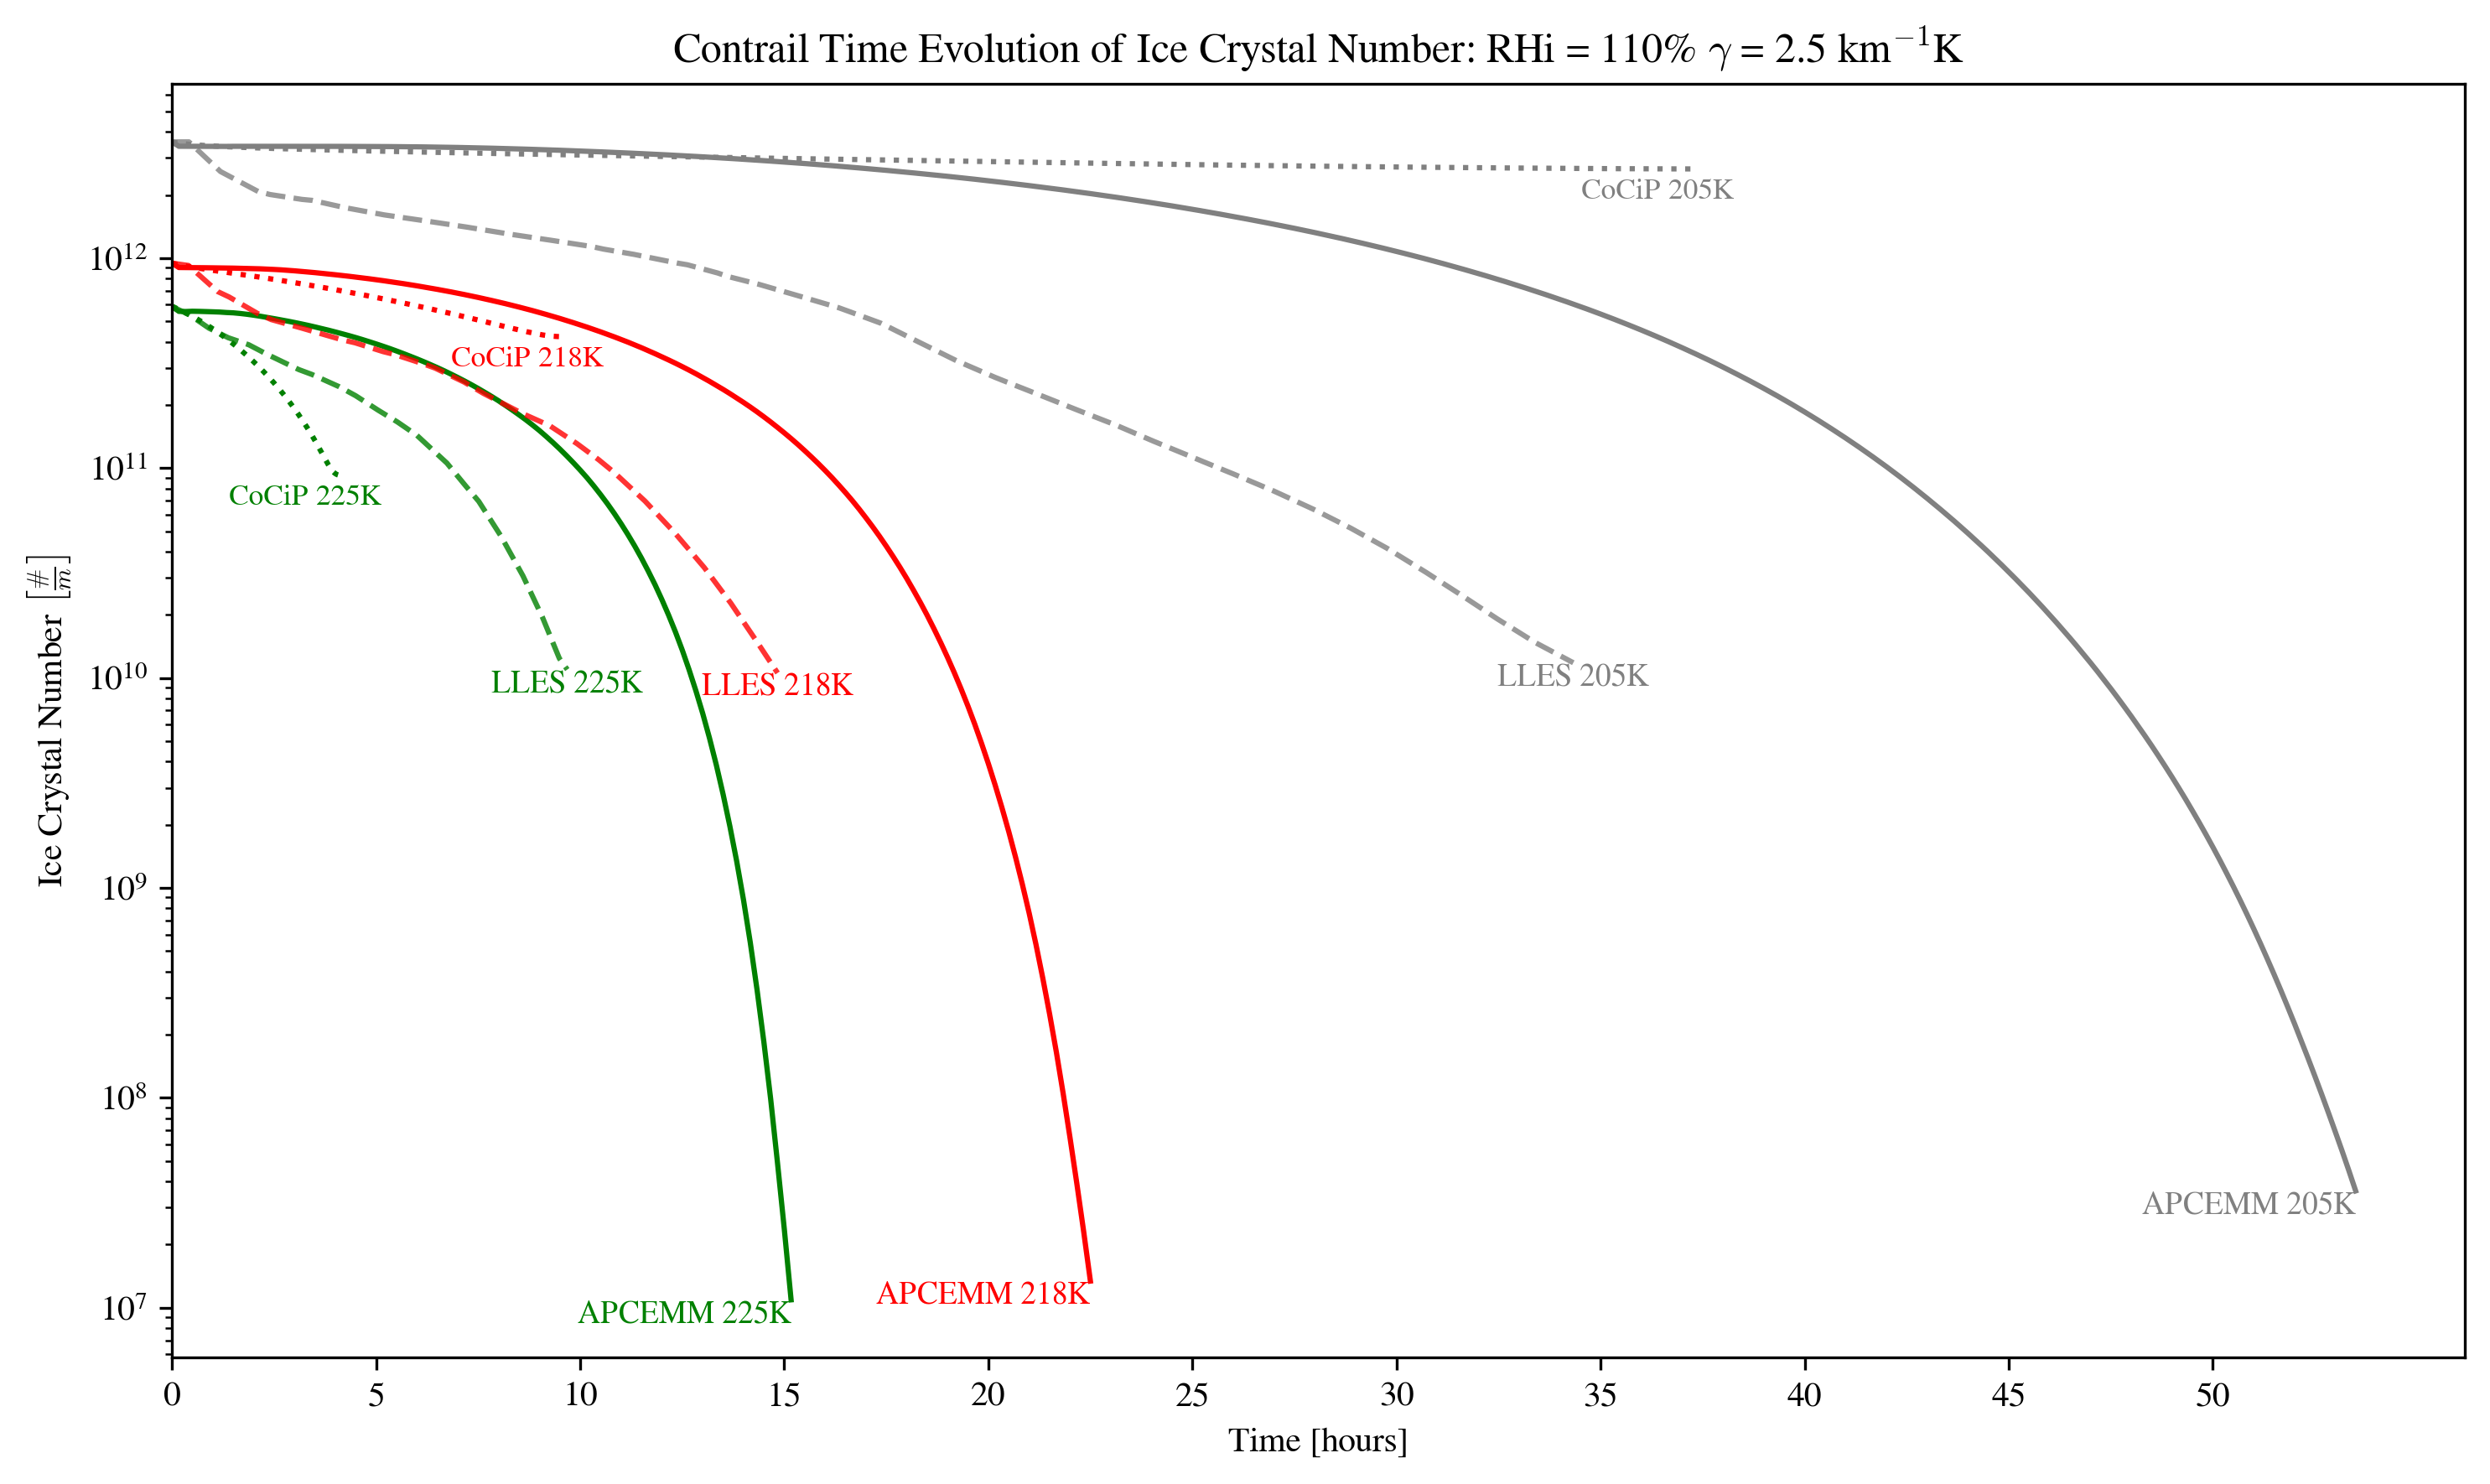

The minimum value of APCEMM's number concentration is: 10903070.0


In [8]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Plot APCEMM bypass results for 110% RHi for each temperature
for temp in temp_groups:
    for test_id in test_ids:
        if f'T{temp}' in test_id and test_id.startswith('110'):
            ds_list = epm_bypass_data[test_id]
            times_arr = np.arange(len(ds_list)) * 10 / 60  # time in hours
            ice_crystal_number = [ds["Number Ice Particles"].item() for ds in ds_list]
            line, = ax.plot(
                times_arr,
                ice_crystal_number,
                color=color_map[temp],
                linestyle='-',
                alpha=1.0,
            )
            # Add label at the end of the line
            ax.text(times_arr[-1], ice_crystal_number[-1], f"APCEMM {temp}K", color=color_map[temp], fontsize=9, va='top', ha='right')

# Plot LES results for 110% RHi for each temperature
for temp in temp_groups:
    for csv_file in num_LES_csv:
        if f'T{temp}' in csv_file and '110' in csv_file:
            df = pd.read_csv(csv_file, header=None)
            line, = ax.plot(
                df.iloc[:,0],
                df.iloc[:,1],
                color=color_map[temp],
                linestyle='--',
                alpha=0.8
            )
            # Add label at the end of the line
            ax.text(df.iloc[:,0].values[-1], df.iloc[:,1].values[-1], f"LLES {temp}K", color=color_map[temp], fontsize=9, va='top', ha='center')

# Plot CoCiP result for 205K, 110% RHi
for temp in temp_groups:
    cocip_key = f'110T{temp}L25'
    if cocip_key in cocip_bypass_data:
        cocip_ds = cocip_bypass_data[cocip_key]
        ax.plot(
            cocip_ds['age_hours'].values,
            cocip_ds['n_ice_per_m'].values,
            linestyle=':',
            color=color_map[temp]
        )
    # Add label at the end of the CoCiP line
    ax.text(cocip_ds['age_hours'].values[-1] + 1, cocip_ds['n_ice_per_m'].values[-1] - (0.1*cocip_ds['n_ice_per_m'].values[-1]), f"CoCiP {temp}K", color=color_map[temp], fontsize=8.5, va='top', ha='right')

ax.set_xlim(left=0)
ax.set_xticks(np.arange(0, 55, 5))
ax.set_xlabel("Time [hours]")
ax.set_ylabel(r'Ice Crystal Number $\left[\frac{\#}{m}\right]$')
ax.set_yscale('log')
ax.set_title(r"Contrail Time Evolution of Ice Crystal Number: RHi = 110% $\gamma$ = 2.5 km$^{-1}$K")
plt.tight_layout()
plt.show()

print(f"The minimum value of APCEMM's number concentration is: {np.min(ice_crystal_number)}")

### 130%

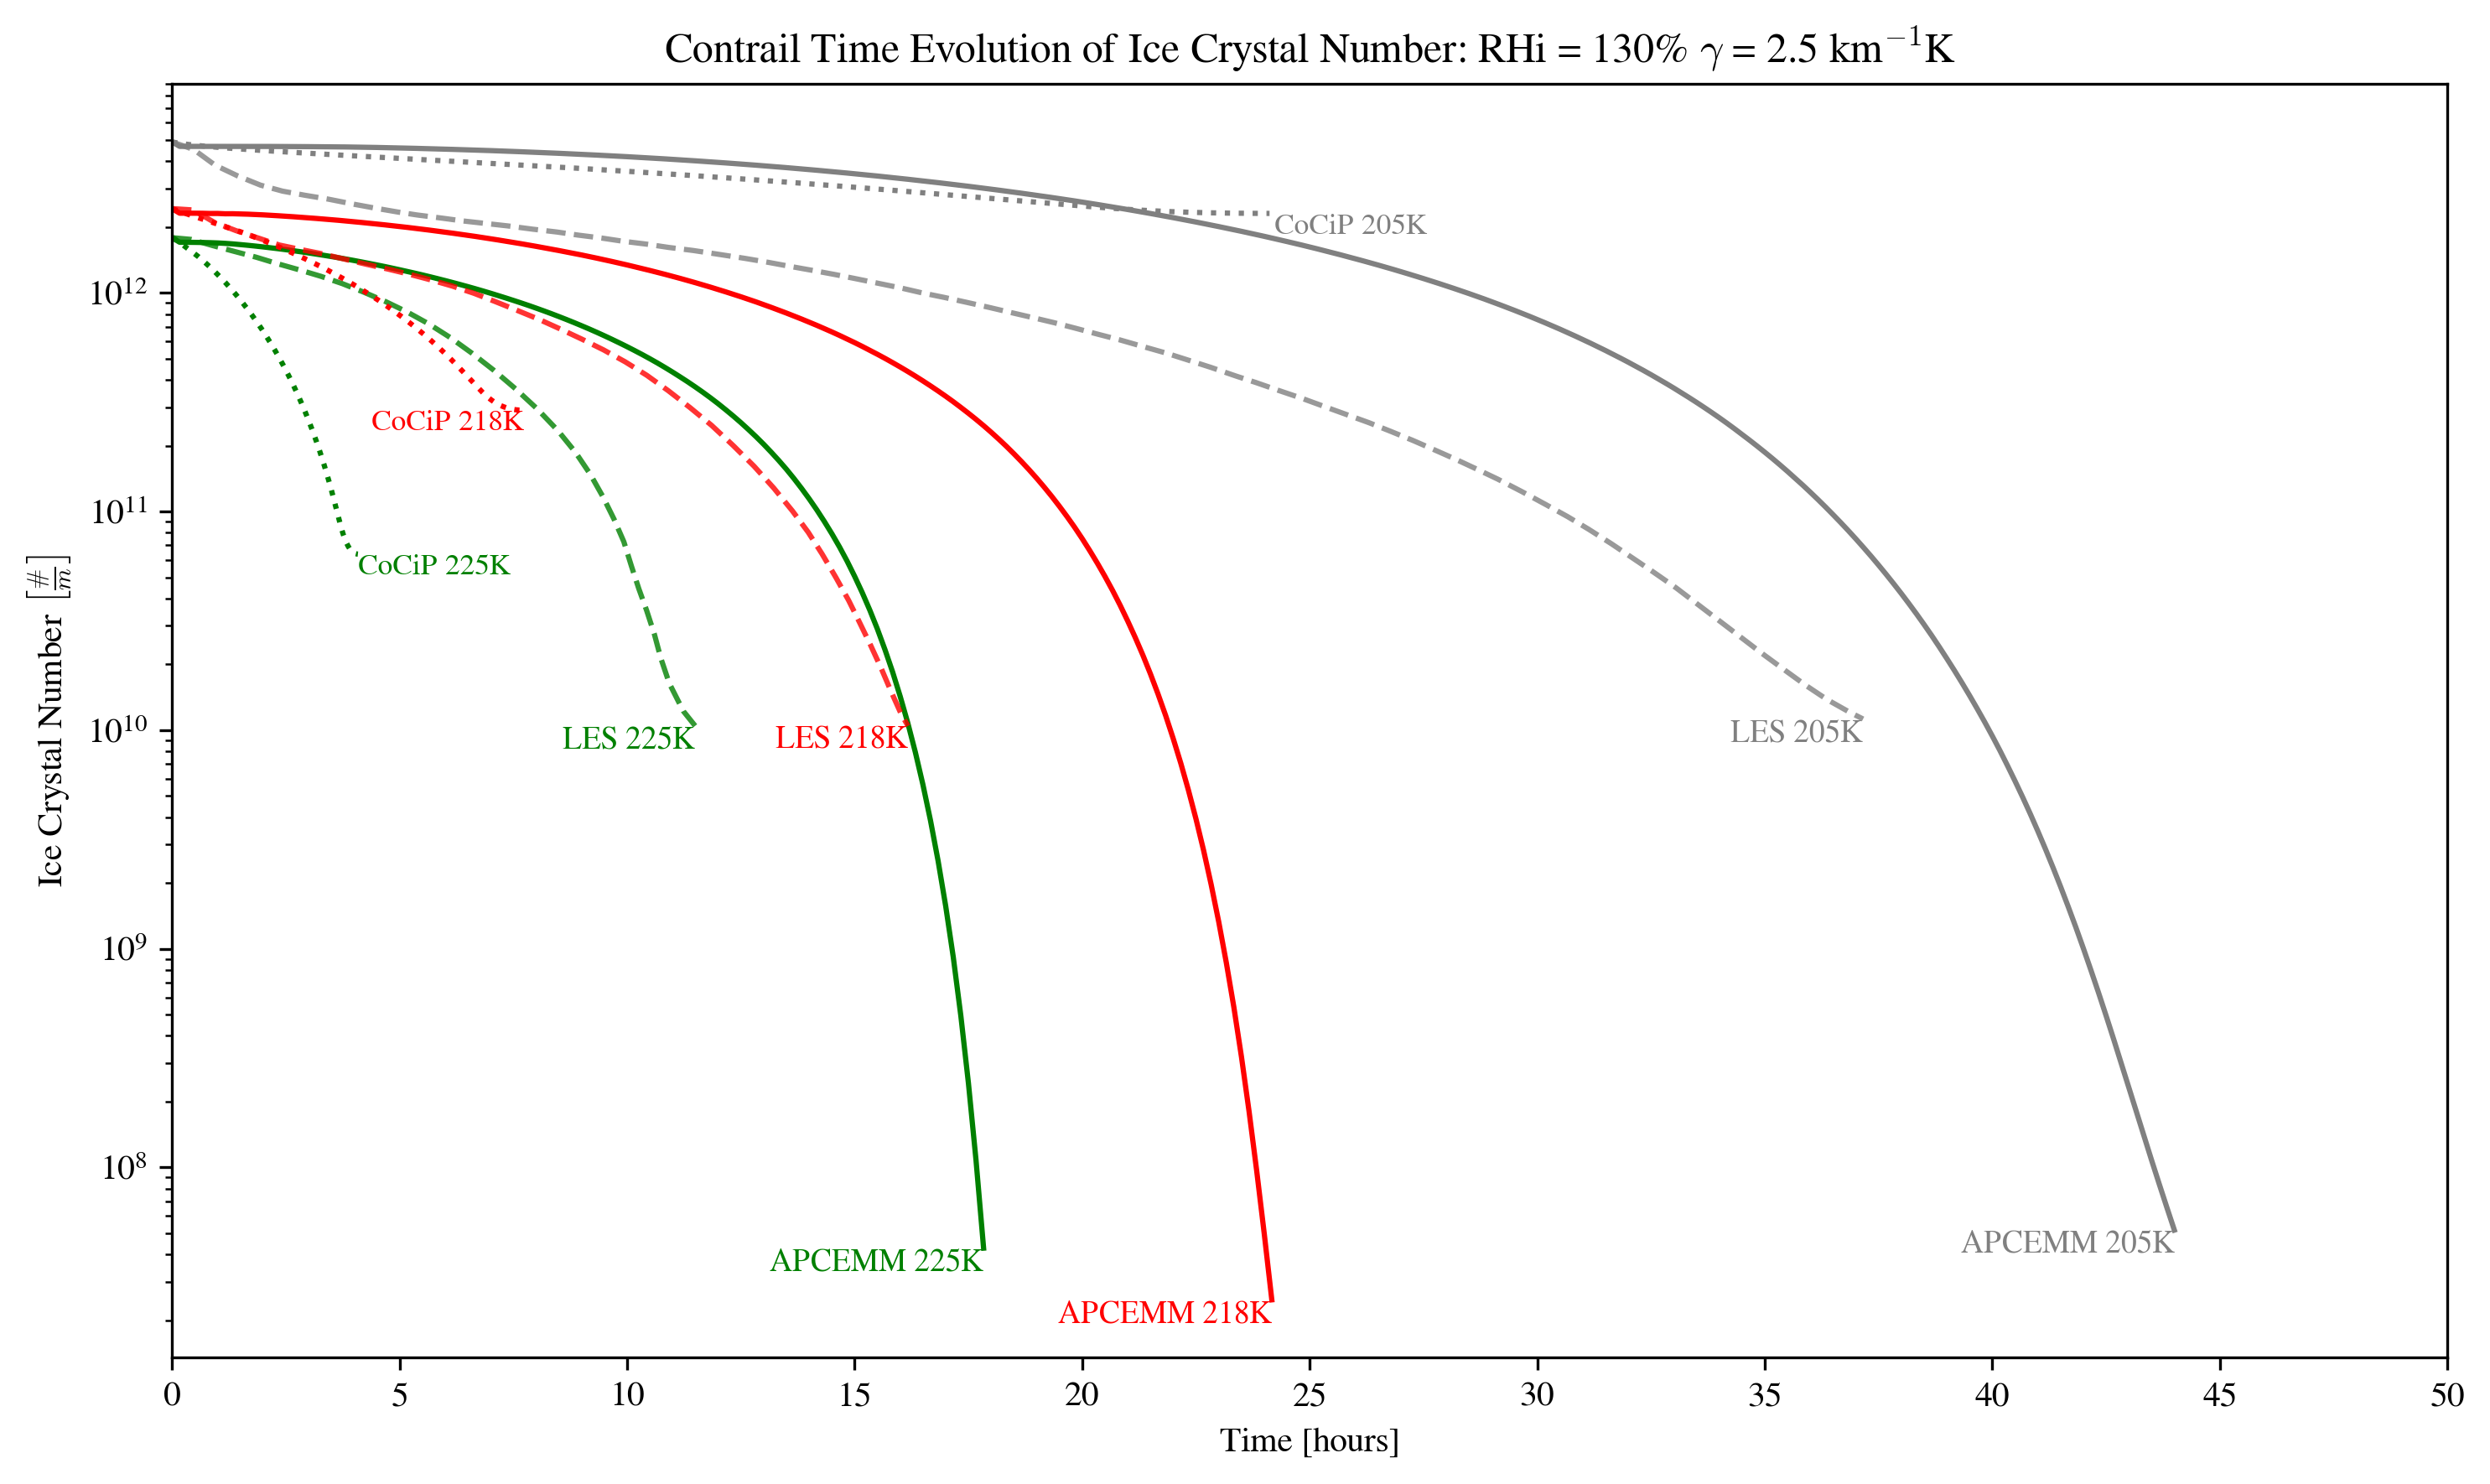

The first value of LES 225K is: 1788210000000.0


In [9]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Plot APCEMM bypass results for 130% RHi for each temperature
for temp in temp_groups:
    for test_id in test_ids:
        if f'T{temp}' in test_id and test_id.startswith('130'):
            ds_list = epm_bypass_data[test_id]
            times_arr = np.arange(len(ds_list)) * 10 / 60  # time in hours
            ice_crystal_number = [ds["Number Ice Particles"].item() for ds in ds_list]
            line, = ax.plot(
                times_arr,
                ice_crystal_number,
                color=color_map[temp],
                linestyle='-',
                alpha=1.0,
            )
            # Add label at the end of the line
            ax.text(times_arr[-1], ice_crystal_number[-1], f"APCEMM {temp}K", color=color_map[temp], fontsize=9, va='top', ha='right')

# Plot LES results for 130% RHi for each temperature
for temp in temp_groups:
    for csv_file in num_LES_csv:
        if f'T{temp}' in csv_file and '130' in csv_file:
            df = pd.read_csv(csv_file, header=None)
            line, = ax.plot(
                df.iloc[:,0],
                df.iloc[:,1],
                color=color_map[temp],
                linestyle='--',
                alpha=0.8
            )
            # Add label at the end of the line
            ax.text(df.iloc[:,0].values[-1], df.iloc[:,1].values[-1], f"LES {temp}K", color=color_map[temp], fontsize=9, va='top', ha='right')

# Plot CoCiP result for 130% RHi for each temperature
for temp in temp_groups:
    cocip_key = f'130T{temp}L25'
    if cocip_key in cocip_bypass_data:
        cocip_ds = cocip_bypass_data[cocip_key]
        ax.plot(
            cocip_ds['age_hours'].values,
            cocip_ds['n_ice_per_m'].values,
            linestyle=':',
            color=color_map[temp]
        )
        # Add label at the end of the CoCiP line
        if temp == '205':
            ax.text(
                cocip_ds['age_hours'].values[-1] + 0.1,
                cocip_ds['n_ice_per_m'].values[-1],
                f"CoCiP {temp}K",
                color=color_map[temp],
                fontsize=8.5,
                va='top',
                ha='left'
            )
        elif temp == '218':
                ax.text(
                cocip_ds['age_hours'].values[-1],
                cocip_ds['n_ice_per_m'].values[-1],
                f"CoCiP {temp}K",
                color=color_map[temp],
                fontsize=8.5,
                va='top',
                ha='right'
            )
        else:
                ax.text(
                cocip_ds['age_hours'].values[-1],
                cocip_ds['n_ice_per_m'].values[-1],
                f"CoCiP {temp}K",
                color=color_map[temp],
                fontsize=8.5,
                va='top',
                ha='left'
            )

ax.set_xlim(left=0)
ax.set_xticks(np.arange(0, 55, 5))
ax.set_xlabel("Time [hours]")
ax.set_ylabel(r'Ice Crystal Number $\left[\frac{\#}{m}\right]$')
ax.set_yscale('log')
ax.set_title(r"Contrail Time Evolution of Ice Crystal Number: RHi = 130% $\gamma$ = 2.5 km$^{-1}$K")
plt.tight_layout()
plt.show()

print(f"The first value of LES 225K is: {df.iloc[0, 1]}")

## Ice Mass Plot

### 110%

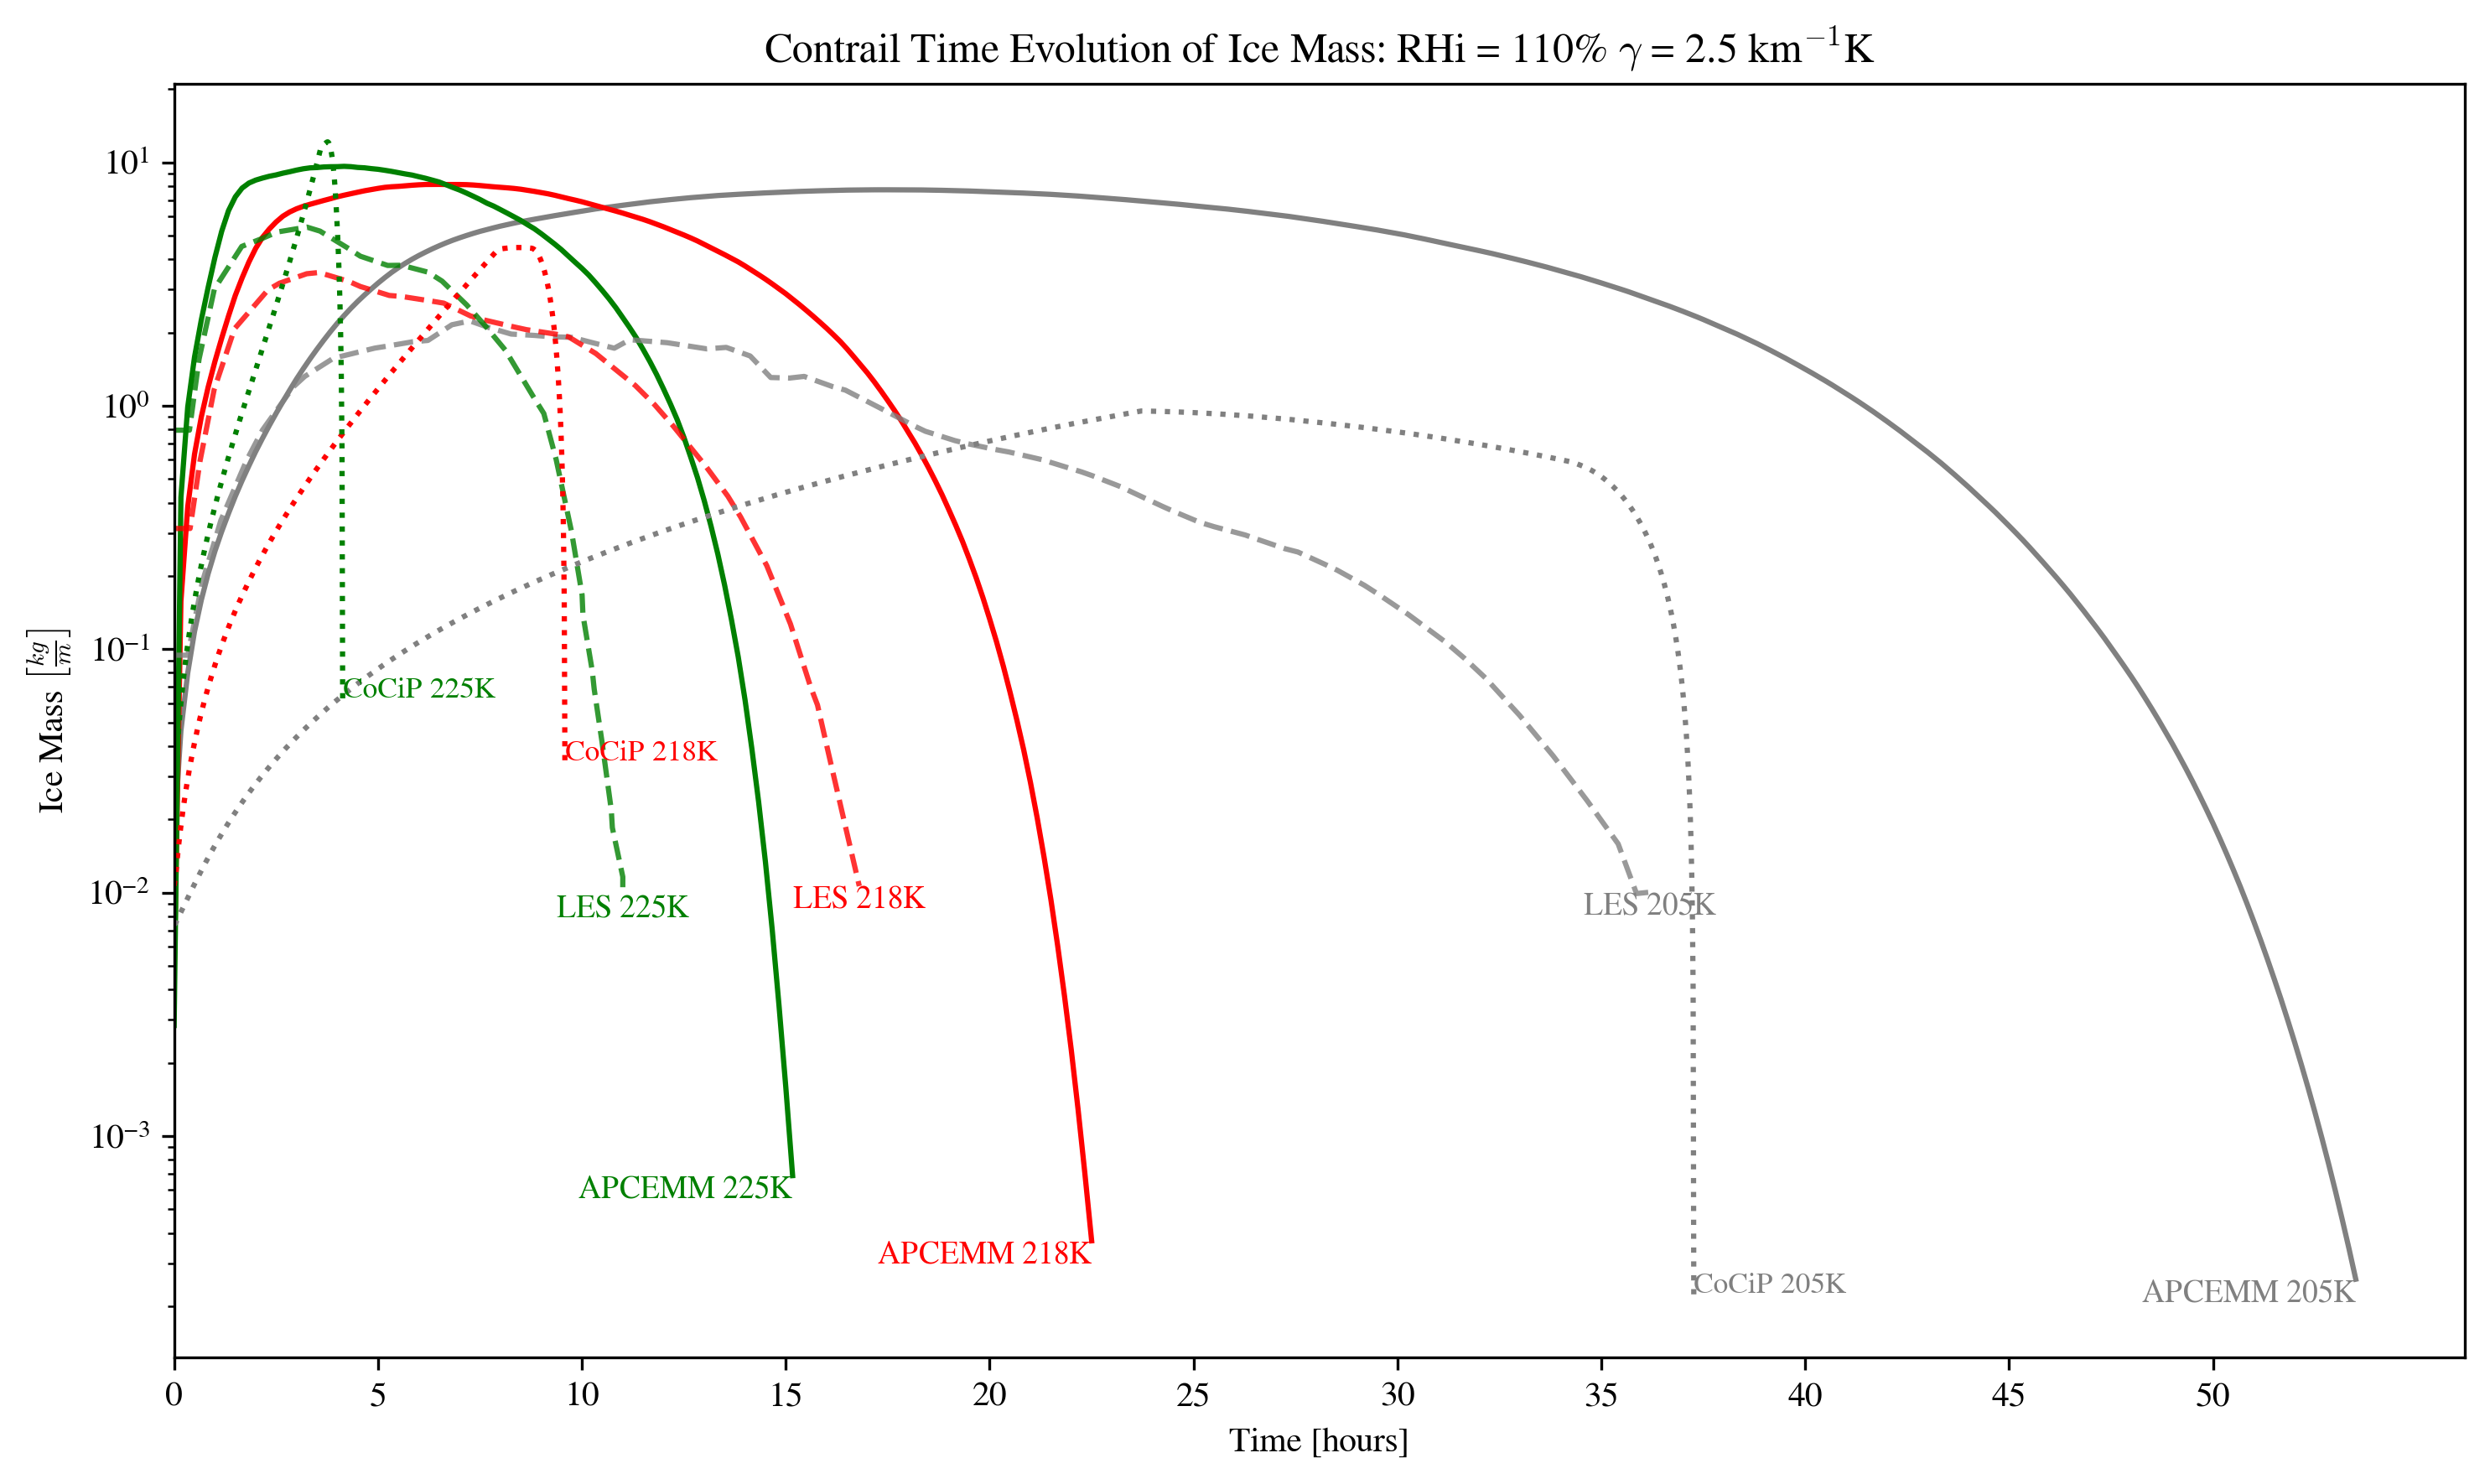

In [10]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Plot APCEMM bypass results for 110% RHi for each temperature
for temp in temp_groups:
    for test_id in test_ids:
        if f'T{temp}' in test_id and test_id.startswith('110'):
            ds_list = epm_bypass_data[test_id]
            times_arr = np.arange(len(ds_list)) * 10 / 60  # time in hours
            ice_mass = [ds["Ice Mass"].item() for ds in ds_list]
            line, = ax.plot(
                times_arr,
                ice_mass,
                color=color_map[temp],
                linestyle='-',
                alpha=1.0,
            )
            # Add label at the end of the line
            ax.text(times_arr[-1], ice_mass[-1], f"APCEMM {temp}K", color=color_map[temp], fontsize=9, va='top', ha='right')

# Plot LES results for 110% RHi for each temperature
for temp in temp_groups:
    for csv_file in mass_LES_csv:
        if f'T{temp}' in csv_file and '110' in csv_file:
            df = pd.read_csv(csv_file, header=None)
            line, = ax.plot(
                df.iloc[:,0],
                df.iloc[:,1],
                color=color_map[temp],
                linestyle='--',
                alpha=0.8
            )
            # Add label at the end of the line
            ax.text(df.iloc[:,0].values[-1], df.iloc[:,1].values[-1], f"LES {temp}K", color=color_map[temp], fontsize=9, va='top', ha='center')

# Plot CoCiP result for 110% RHi
for temp in temp_groups:
    cocip_key = f'110T{temp}L25'
    if cocip_key in cocip_bypass_data:
        cocip_ds = cocip_bypass_data[cocip_key]
        cocip_ice_mass = cocip_ds['n_ice_per_m'].values * (4/3 * np.pi *(cocip_ds['r_ice_vol'].values)**3) * 917 # Number of crystals * 4/3 pi (ice particle mean radius [m])**3 * 917 [kg/m3] density of ice
        ax.plot(
            cocip_ds['age_hours'].values,
            cocip_ice_mass,
            linestyle=':',
            color=color_map[temp]
        )
    # Add label at the end of the CoCiP line
    ax.text(cocip_ds['age_hours'].values[-1], cocip_ice_mass[-1], f"CoCiP {temp}K", color=color_map[temp], fontsize=8.5, va='bottom', ha='left')

ax.set_xlim(left=0)
ax.set_xticks(np.arange(0, 55, 5))
ax.set_xlabel("Time [hours]")
ax.set_ylabel(r'Ice Mass $\left[\frac{kg}{m}\right]$')
ax.set_yscale('log')
ax.set_title(r"Contrail Time Evolution of Ice Mass: RHi = 110% $\gamma$ = 2.5 km$^{-1}$K")
plt.tight_layout()
plt.show()


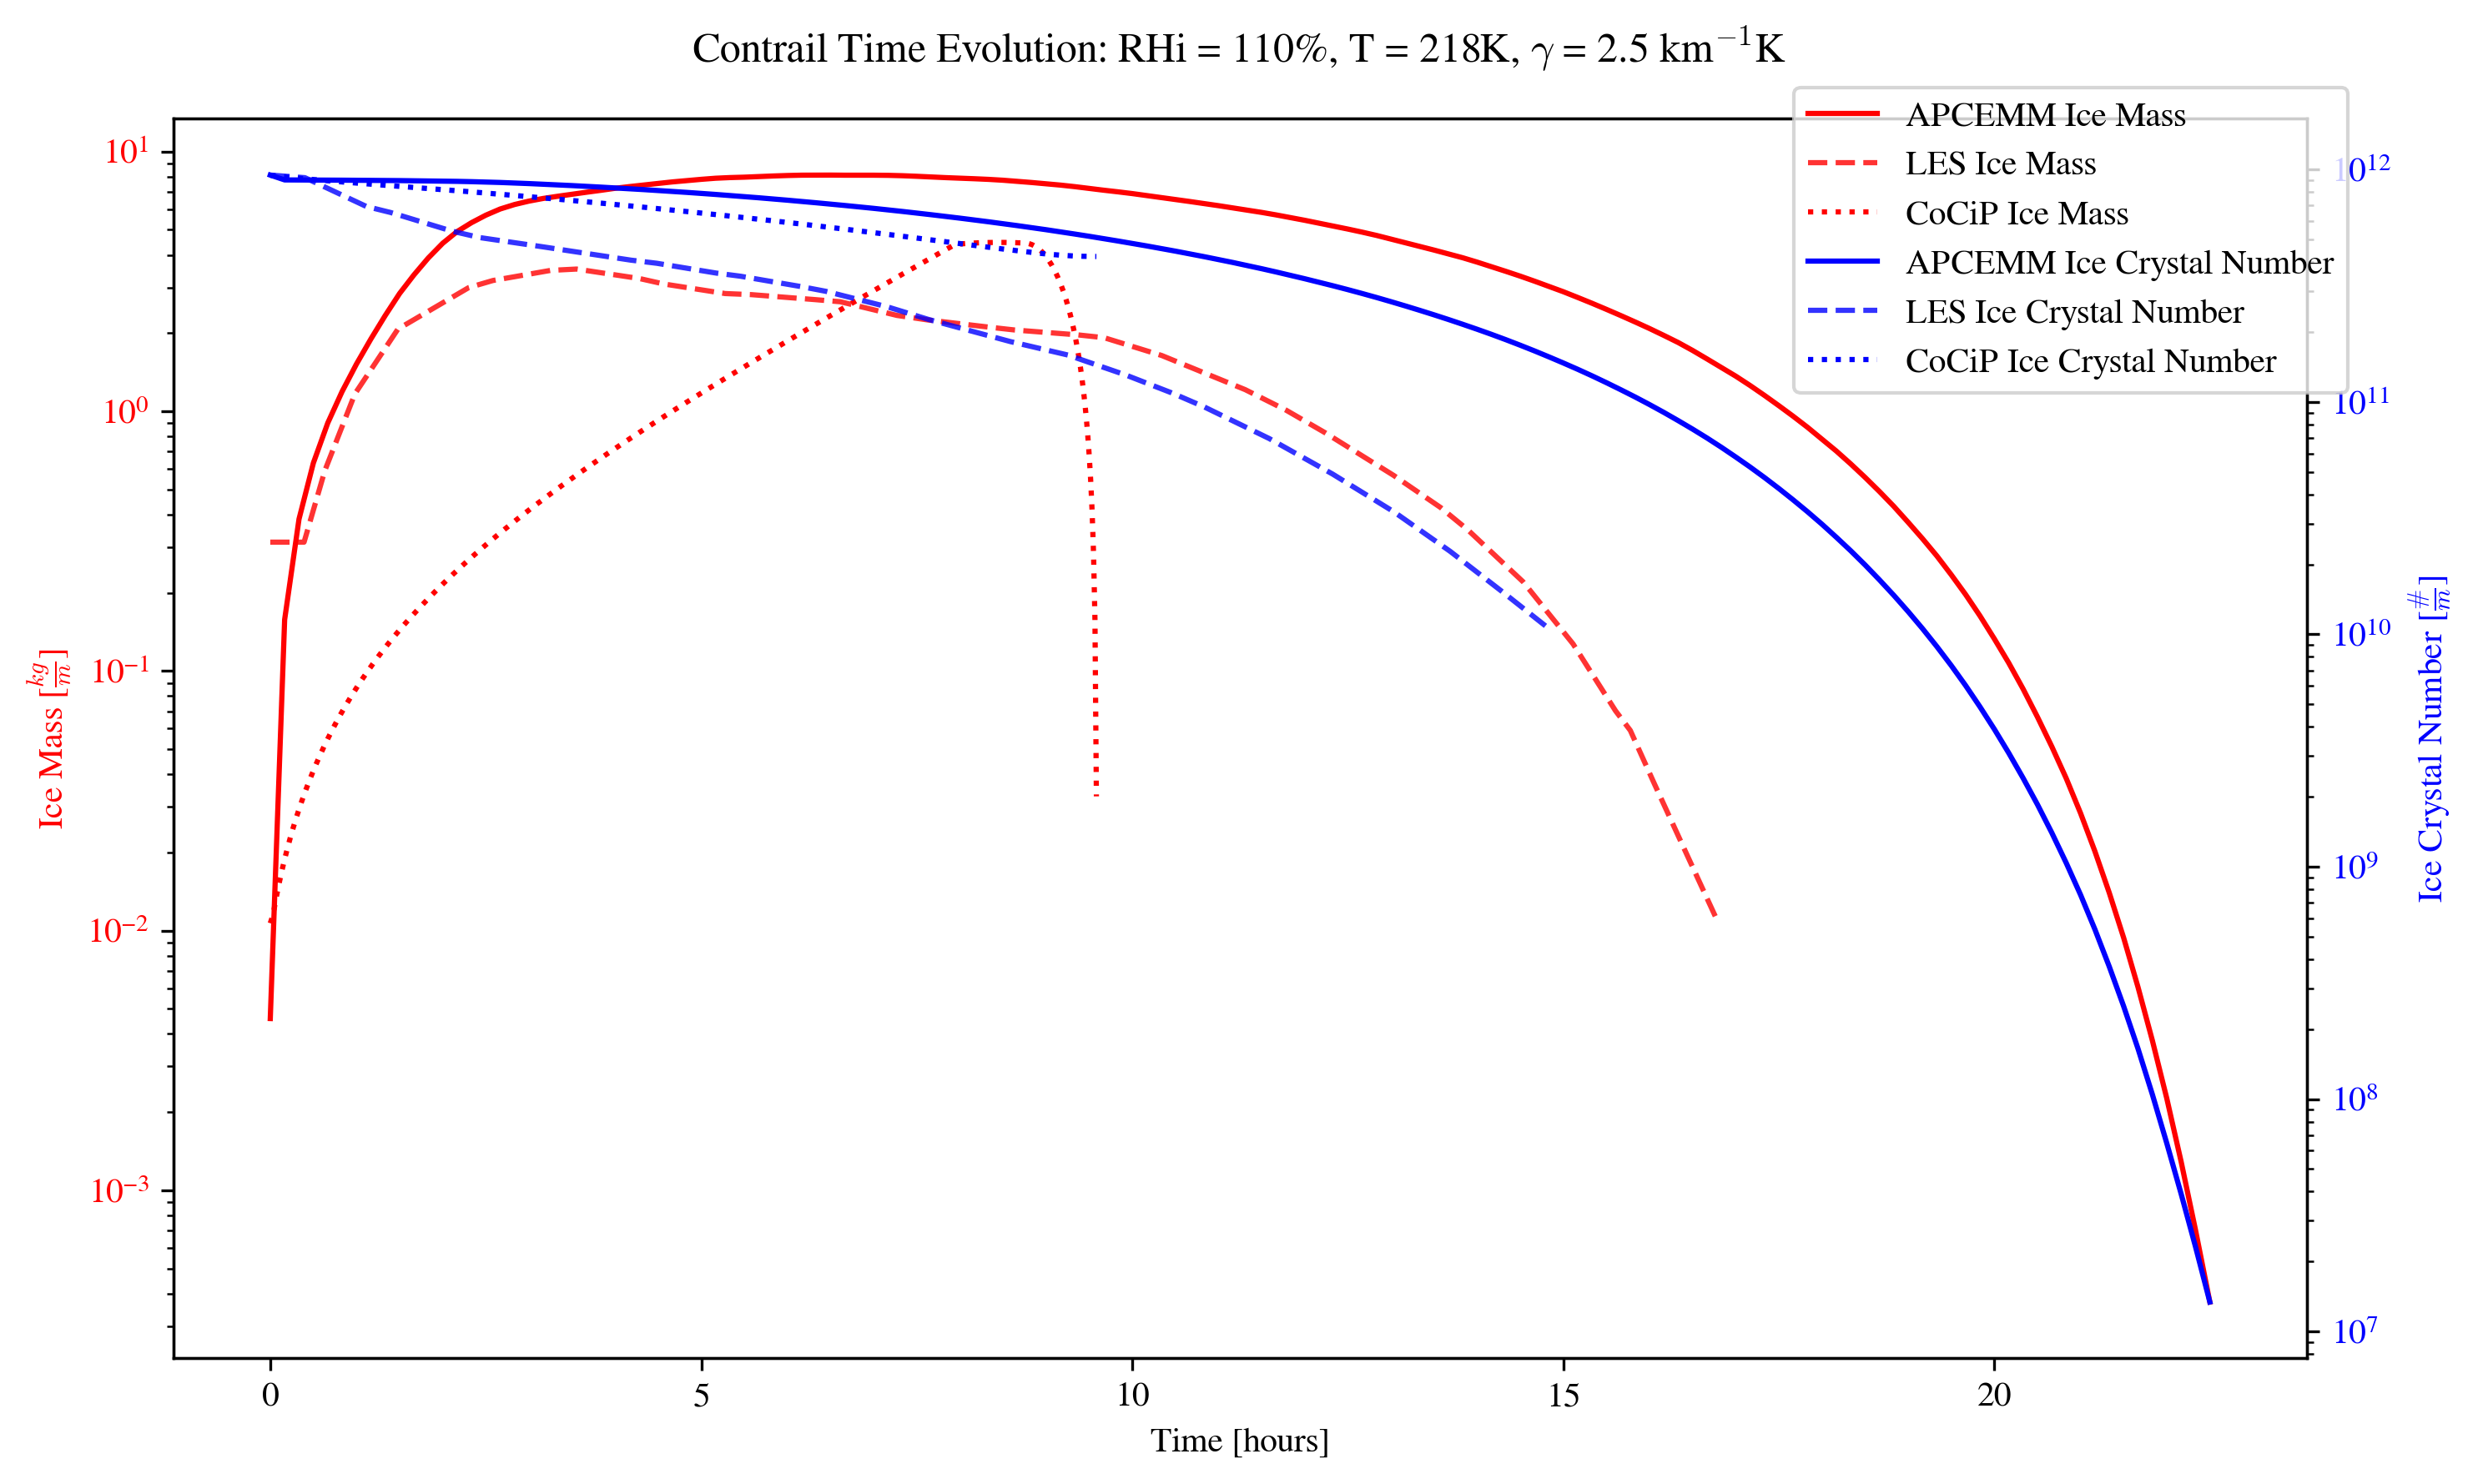

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)

temp = '218'
test_id = f'110T{temp}L25'
ds_list = epm_bypass_data[test_id]
times_arr = np.arange(len(ds_list)) * 10 / 60  # time in hours

# APCEMM ice mass
ice_mass = [ds["Ice Mass"].item() for ds in ds_list]
ax1.plot(times_arr, ice_mass, color=color_map[temp], linestyle='-', label='APCEMM Ice Mass')

# LES ice mass
for csv_file in mass_LES_csv:
    if f'T{temp}' in csv_file and '110' in csv_file:
        df_mass = pd.read_csv(csv_file, header=None)
        ax1.plot(df_mass.iloc[:,0], df_mass.iloc[:,1], color=color_map[temp], linestyle='--', alpha=0.8, label='LES Ice Mass')

# CoCiP ice mass
cocip_key = f'110T{temp}L25'
if cocip_key in cocip_bypass_data:
    cocip_ds = cocip_bypass_data[cocip_key]
    cocip_ice_mass = cocip_ds['n_ice_per_m'].values * (4/3 * np.pi * (cocip_ds['r_ice_vol'].values)**3) * 917
    ax1.plot(cocip_ds['age_hours'].values, cocip_ice_mass, color=color_map[temp], linestyle=':', label='CoCiP Ice Mass')

ax1.set_xlabel("Time [hours]")
ax1.set_ylabel(r'Ice Mass [$\frac{kg}{m}$]', color=color_map[temp])
ax1.tick_params(axis='y', labelcolor=color_map[temp])
ax1.set_yscale('log')

# Twin axis for ice crystal number
ax2 = ax1.twinx()
ice_crystal_number = [ds["Number Ice Particles"].item() for ds in ds_list]
ax2.plot(times_arr, ice_crystal_number, color='blue', linestyle='-', label='APCEMM Ice Crystal Number')

for csv_file in num_LES_csv:
    if f'T{temp}' in csv_file and '110' in csv_file:
        df_num = pd.read_csv(csv_file, header=None)
        ax2.plot(df_num.iloc[:,0], df_num.iloc[:,1], color='blue', linestyle='--', alpha=0.8, label='LES Ice Crystal Number')

# CoCiP ice crystal number
if cocip_key in cocip_bypass_data:
    ax2.plot(cocip_ds['age_hours'].values, cocip_ds['n_ice_per_m'].values, color='blue', linestyle=':', label='CoCiP Ice Crystal Number')

ax2.set_ylabel(r'Ice Crystal Number [$\frac{\#}{m}$]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_yscale('log')

fig.suptitle(r"Contrail Time Evolution: RHi = 110%, T = 218K, $\gamma$ = 2.5 km$^{-1}$K")
fig.tight_layout()
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
plt.show()

### 130%

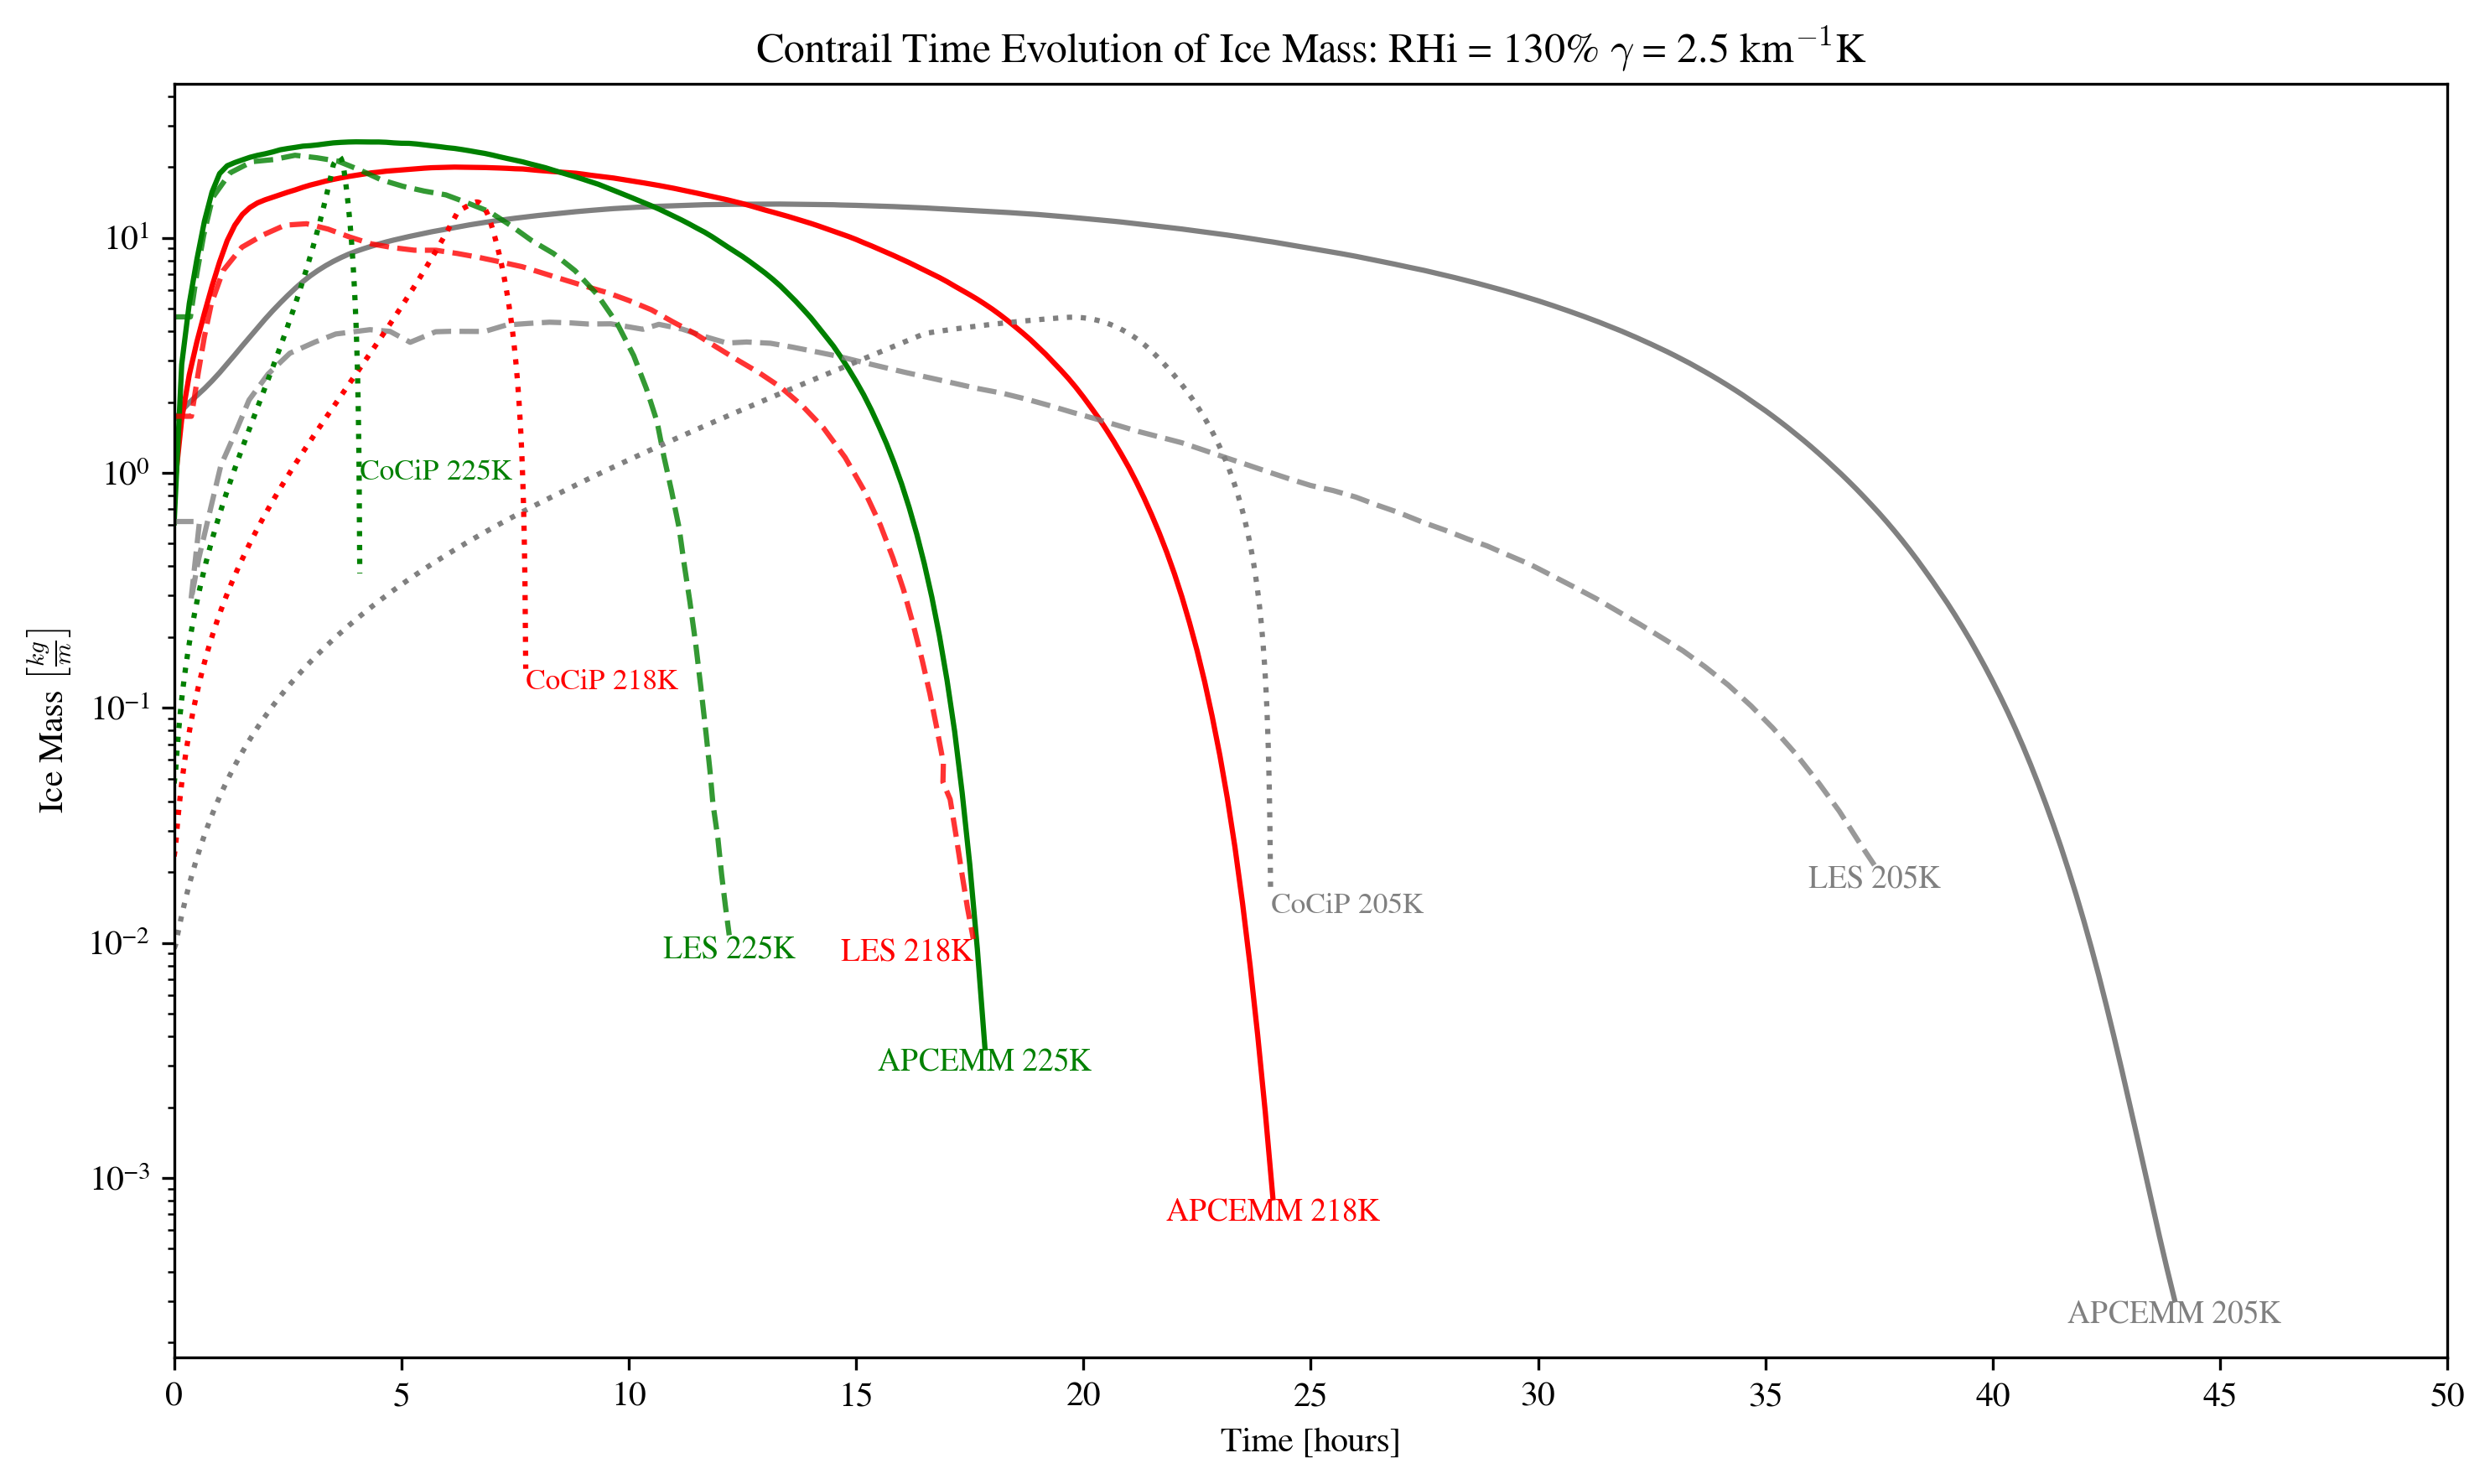

In [12]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Plot APCEMM bypass results for 130% RHi for each temperature
for temp in temp_groups:
    for test_id in test_ids:
        if f'T{temp}' in test_id and test_id.startswith('130'):
            ds_list = epm_bypass_data[test_id]
            times_arr = np.arange(len(ds_list)) * 10 / 60  # time in hours
            ice_mass = [ds["Ice Mass"].item() for ds in ds_list]
            line, = ax.plot(
                times_arr,
                ice_mass,
                color=color_map[temp],
                linestyle='-',
                alpha=1.0,
            )
            # Add label at the end of the line
            ax.text(times_arr[-1], ice_mass[-1], f"APCEMM {temp}K", color=color_map[temp], fontsize=9, va='top', ha='center')

# Plot LES results for 130% RHi for each temperature
for temp in temp_groups:
    for csv_file in mass_LES_csv:
        if f'T{temp}' in csv_file and '130' in csv_file:
            df = pd.read_csv(csv_file, header=None)
            line, = ax.plot(
                df.iloc[:,0],
                df.iloc[:,1],
                color=color_map[temp],
                linestyle='--',
                alpha=0.8
            )
            # Add label at the end of the line
            if temp == '218':
                ax.text(df.iloc[:,0].values[-1], df.iloc[:,1].values[-1], f"LES {temp}K", color=color_map[temp], fontsize=9, va='top', ha='right')
            else:
                ax.text(df.iloc[:,0].values[-1], df.iloc[:,1].values[-1], f"LES {temp}K", color=color_map[temp], fontsize=9, va='top', ha='center')

# Plot CoCiP result for 130% RHi
for temp in temp_groups:
    cocip_key = f'130T{temp}L25'
    if cocip_key in cocip_bypass_data:
        cocip_ds = cocip_bypass_data[cocip_key]
        cocip_ice_mass = cocip_ds['n_ice_per_m'].values * (4/3 * np.pi *(cocip_ds['r_ice_vol'].values)**3) * 917 # Number of crystals * 4/3 pi (ice particle mean radius [m])**3 * 917 [kg/m3] density of ice
        ax.plot(
            cocip_ds['age_hours'].values,
            cocip_ice_mass,
            linestyle=':',
            color=color_map[temp]
        )
    # Add label at the end of the CoCiP line
    if temp == '225':
        ax.text(cocip_ds['age_hours'].values[-1], cocip_ice_mass[-1] + 0.5, f"CoCiP {temp}K", color=color_map[temp], fontsize=8.5, va='bottom', ha='left')
    else:
        ax.text(cocip_ds['age_hours'].values[-1], cocip_ice_mass[-1], f"CoCiP {temp}K", color=color_map[temp], fontsize=8.5, va='top', ha='left')

ax.set_xlim(left=0)
ax.set_xticks(np.arange(0, 55, 5))
ax.set_xlabel("Time [hours]")
ax.set_ylabel(r'Ice Mass $\left[\frac{kg}{m}\right]$')
ax.set_yscale('log')
ax.set_title(r"Contrail Time Evolution of Ice Mass: RHi = 130% $\gamma$ = 2.5 km$^{-1}$K")
plt.tight_layout()
plt.show()


## Mass and Number Results (ALL CASES)

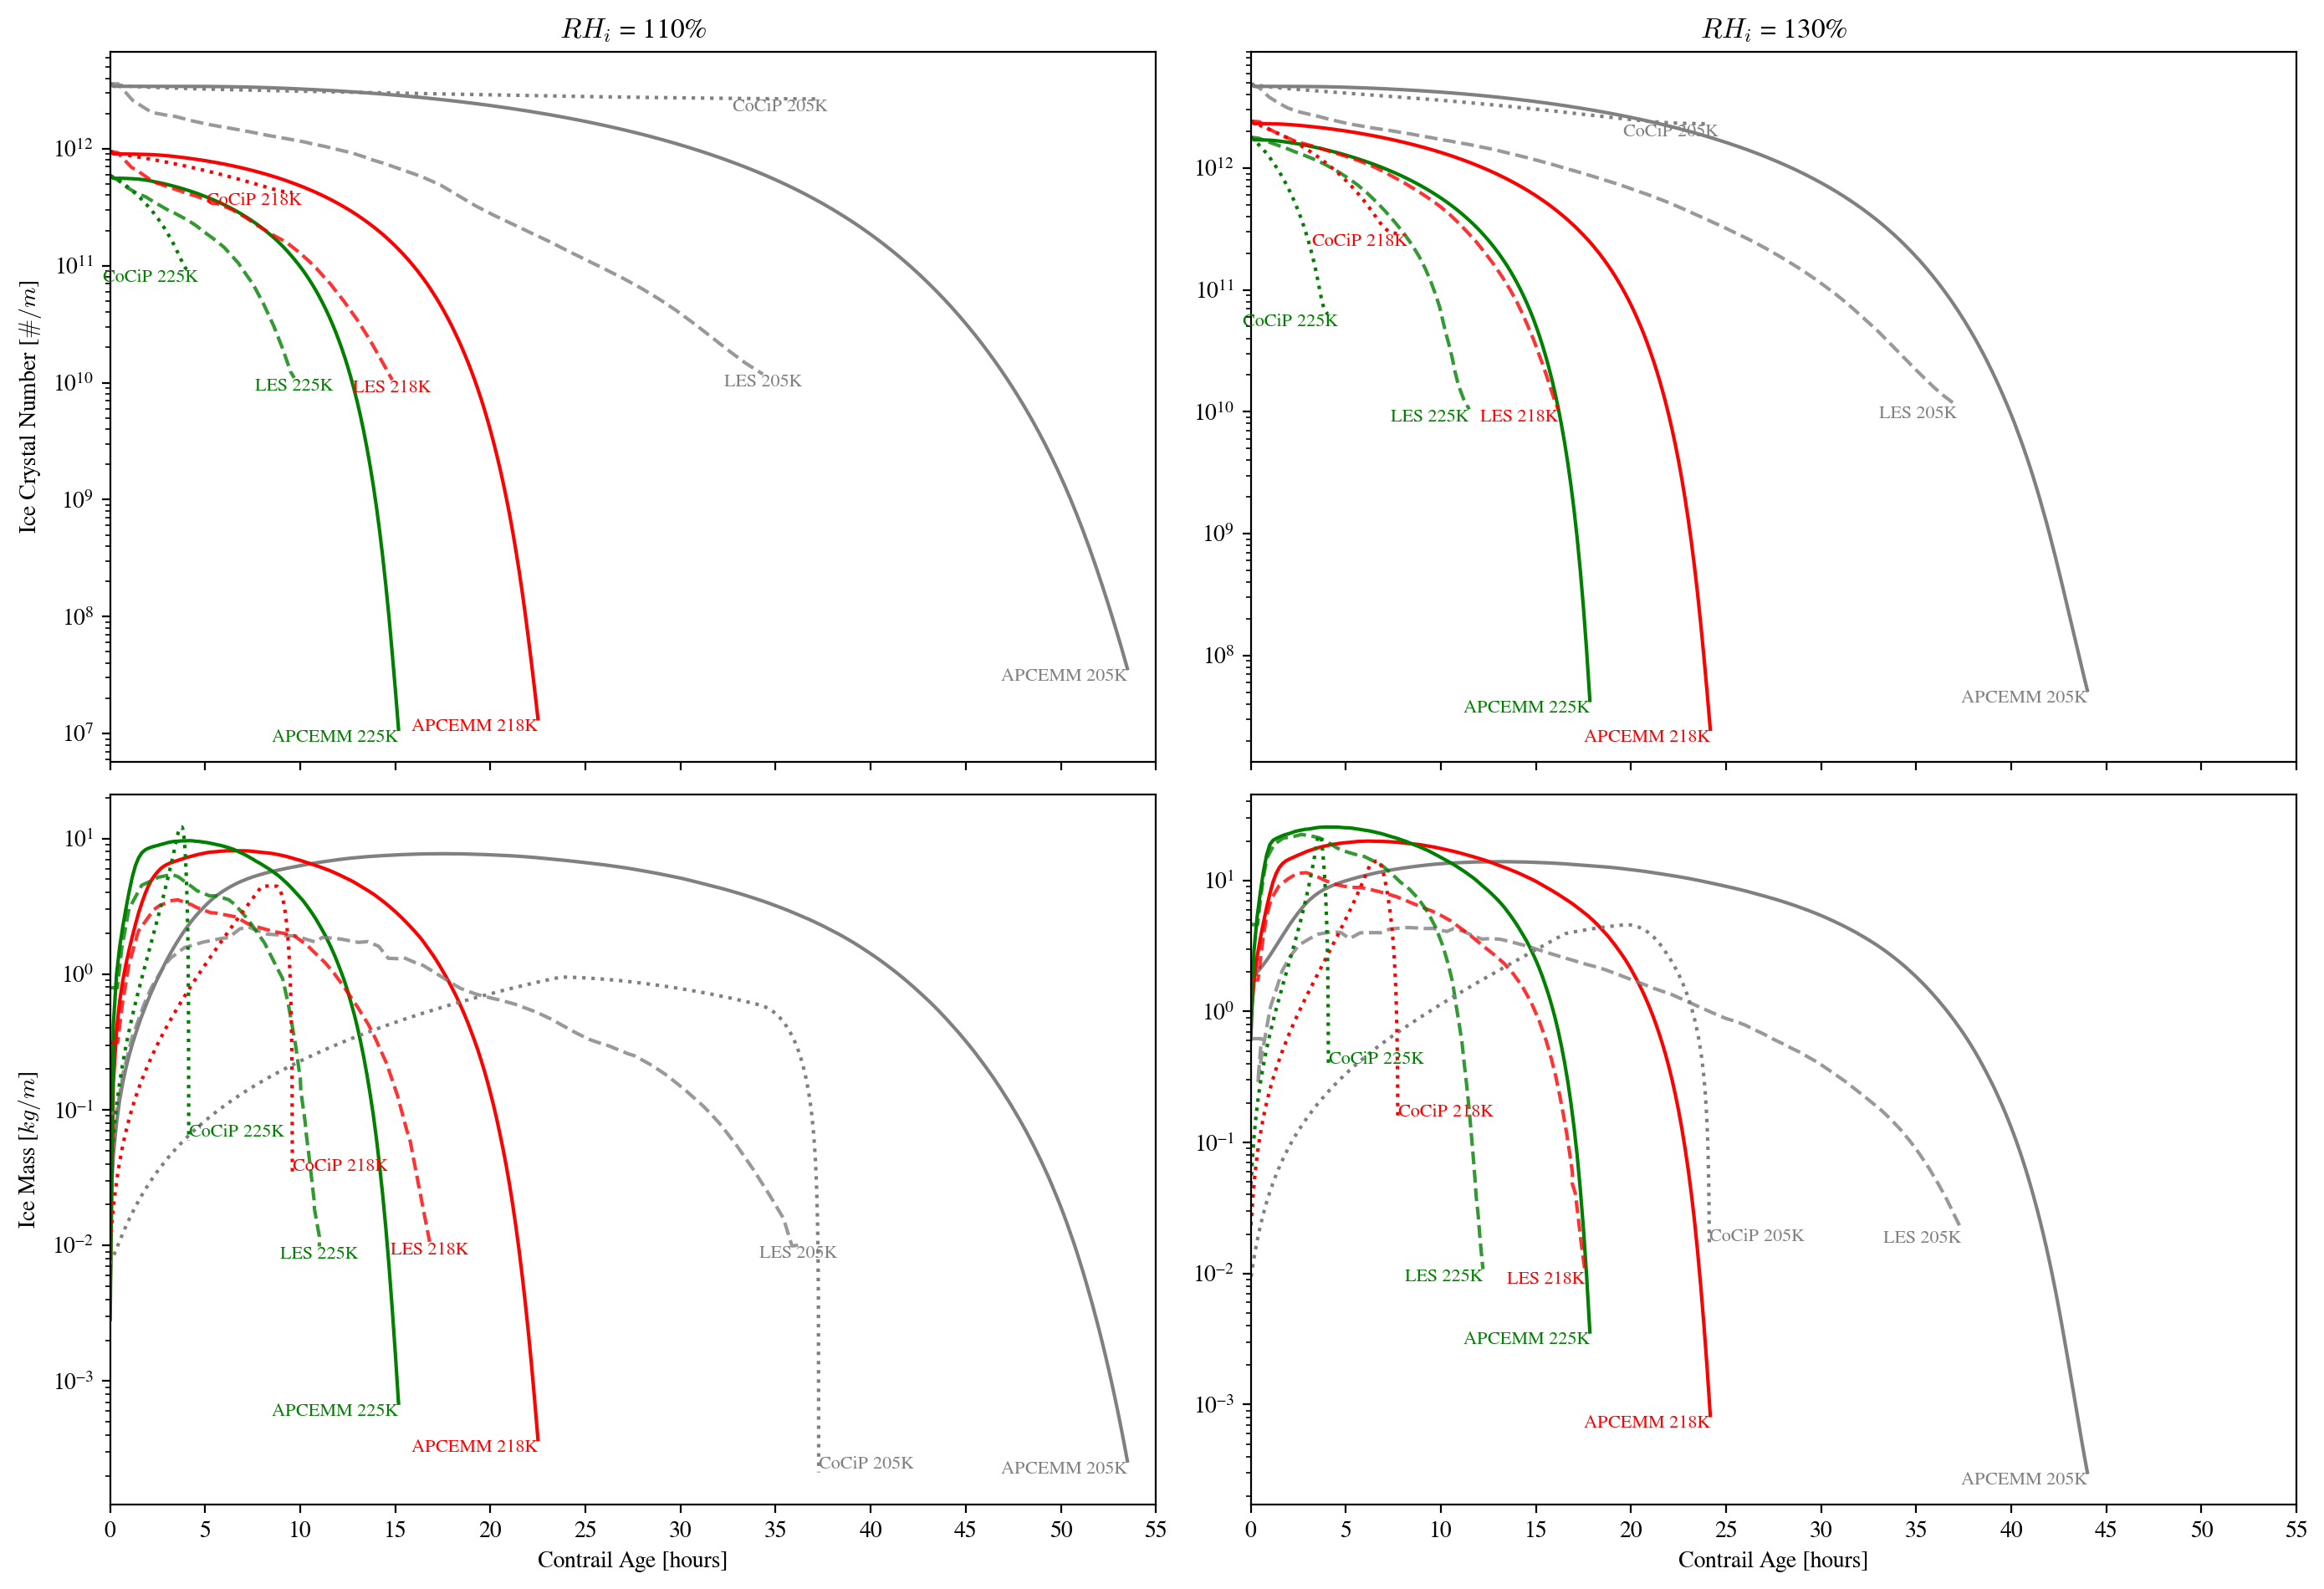

In [19]:
# 2x2 subplot: column 1 = 110% (top: number, bottom: mass), column 2 = 130%
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=200, sharex='col')
(ax_num_110, ax_num_130), (ax_mass_110, ax_mass_130) = axes

# common x formatting: extend to 55 hours
for ax in [ax_num_110, ax_num_130, ax_mass_110, ax_mass_130]:
    ax.set_xlim(left=0, right=55)
    ax.set_xticks(np.arange(0, 56, 5))

# Top-left: Number concentration (110%)
for temp in temp_groups:
    for tid in test_ids:
        if tid.startswith('110') and f'T{temp}' in tid:
            ds_list = epm_bypass_data[tid]
            times_arr = np.arange(len(ds_list)) * 10 / 60
            ice_num = [ds["Number Ice Particles"].item() for ds in ds_list]
            ax_num_110.plot(times_arr, ice_num, color=color_map[temp], linestyle='-', alpha=1.0)
            ax_num_110.text(times_arr[-1], ice_num[-1], f"APCEMM {temp}K", color=color_map[temp], fontsize=8, va='top', ha='right')

# LES number (110%)
for temp in temp_groups:
    for fpath in num_LES_csv:
        if f'T{temp}' in fpath and '110' in fpath:
            df_ = pd.read_csv(fpath, header=None)
            ax_num_110.plot(df_.iloc[:,0], df_.iloc[:,1], color=color_map[temp], linestyle='--', alpha=0.8)
            ax_num_110.text(df_.iloc[:,0].values[-1], df_.iloc[:,1].values[-1], f"LES {temp}K", color=color_map[temp], fontsize=8, va='top', ha='center')

# CoCiP number (110%)
for temp in temp_groups:
    key = f'110T{temp}L25'
    if key in cocip_bypass_data:
        cds = cocip_bypass_data[key]
        ax_num_110.plot(cds['age_hours'].values, cds['n_ice_per_m'].values, linestyle=':', color=color_map[temp])
        ax_num_110.text(cds['age_hours'].values[-1] + 0.5, cds['n_ice_per_m'].values[-1], f"CoCiP {temp}K", color=color_map[temp], fontsize=8, va='top', ha='right')

ax_num_110.set_yscale('log')
ax_num_110.set_ylabel(r'Ice Crystal Number [$\#/m$]')
ax_num_110.set_title(r"$RH_{i}$ = 110%")

# Top-right: Number concentration (130%)
for temp in temp_groups:
    for tid in test_ids:
        if tid.startswith('130') and f'T{temp}' in tid:
            ds_list = epm_bypass_data[tid]
            times_arr = np.arange(len(ds_list)) * 10 / 60
            ice_num = [ds["Number Ice Particles"].item() for ds in ds_list]
            ax_num_130.plot(times_arr, ice_num, color=color_map[temp], linestyle='-', alpha=1.0)
            ax_num_130.text(times_arr[-1], ice_num[-1], f"APCEMM {temp}K", color=color_map[temp], fontsize=8, va='top', ha='right')

# LES number (130%)
for temp in temp_groups:
    for fpath in num_LES_csv:
        if f'T{temp}' in fpath and '130' in fpath:
            df_ = pd.read_csv(fpath, header=None)
            ax_num_130.plot(df_.iloc[:,0], df_.iloc[:,1], color=color_map[temp], linestyle='--', alpha=0.8)
            ax_num_130.text(df_.iloc[:,0].values[-1], df_.iloc[:,1].values[-1], f"LES {temp}K", color=color_map[temp], fontsize=8, va='top', ha='right')

# CoCiP number (130%)
for temp in temp_groups:
    key = f'130T{temp}L25'
    if key in cocip_bypass_data:
        cds = cocip_bypass_data[key]
        ax_num_130.plot(cds['age_hours'].values, cds['n_ice_per_m'].values, linestyle=':', color=color_map[temp])
        ax_num_130.text(cds['age_hours'].values[-1] + 0.5, cds['n_ice_per_m'].values[-1], f"CoCiP {temp}K", color=color_map[temp], fontsize=8, va='top', ha='right')

ax_num_130.set_yscale('log')
ax_num_130.set_title(r"$RH_{i}$ = 130%")

# Bottom-left: Ice mass (110%)
for temp in temp_groups:
    for tid in test_ids:
        if tid.startswith('110') and f'T{temp}' in tid:
            ds_list = epm_bypass_data[tid]
            times_arr = np.arange(len(ds_list)) * 10 / 60
            ice_mass = [ds["Ice Mass"].item() for ds in ds_list]
            ax_mass_110.plot(times_arr, ice_mass, color=color_map[temp], linestyle='-', alpha=1.0)
            ax_mass_110.text(times_arr[-1], ice_mass[-1], f"APCEMM {temp}K", color=color_map[temp], fontsize=8, va='top', ha='right')

# LES mass (110%)
for temp in temp_groups:
    for fpath in mass_LES_csv:
        if f'T{temp}' in fpath and '110' in fpath:
            dfm = pd.read_csv(fpath, header=None)
            ax_mass_110.plot(dfm.iloc[:,0], dfm.iloc[:,1], color=color_map[temp], linestyle='--', alpha=0.8)
            ax_mass_110.text(dfm.iloc[:,0].values[-1], dfm.iloc[:,1].values[-1], f"LES {temp}K", color=color_map[temp], fontsize=8, va='top', ha='center')

# CoCiP mass (110%)
for temp in temp_groups:
    key = f'110T{temp}L25'
    if key in cocip_bypass_data:
        cds = cocip_bypass_data[key]
        cocip_mass = cds['n_ice_per_m'].values * (4/3 * np.pi * (cds['r_ice_vol'].values)**3) * 917
        ax_mass_110.plot(cds['age_hours'].values, cocip_mass, linestyle=':', color=color_map[temp])
        ax_mass_110.text(cds['age_hours'].values[-1], cocip_mass[-1], f"CoCiP {temp}K", color=color_map[temp], fontsize=8, va='bottom', ha='left')

ax_mass_110.set_yscale('log')
ax_mass_110.set_xlabel("Contrail Age [hours]")
ax_mass_110.set_ylabel(r'Ice Mass [$kg/m$]')

# Bottom-right: Ice mass (130%)
for temp in temp_groups:
    for tid in test_ids:
        if tid.startswith('130') and f'T{temp}' in tid:
            ds_list = epm_bypass_data[tid]
            times_arr = np.arange(len(ds_list)) * 10 / 60
            ice_mass = [ds["Ice Mass"].item() for ds in ds_list]
            ax_mass_130.plot(times_arr, ice_mass, color=color_map[temp], linestyle='-', alpha=1.0)
            ax_mass_130.text(times_arr[-1], ice_mass[-1], f"APCEMM {temp}K", color=color_map[temp], fontsize=8, va='top', ha='right')

# LES mass (130%)
for temp in temp_groups:
    for fpath in mass_LES_csv:
        if f'T{temp}' in fpath and '130' in fpath:
            dfm = pd.read_csv(fpath, header=None)
            ax_mass_130.plot(dfm.iloc[:,0], dfm.iloc[:,1], color=color_map[temp], linestyle='--', alpha=0.8)
            ax_mass_130.text(dfm.iloc[:,0].values[-1], dfm.iloc[:,1].values[-1], f"LES {temp}K", color=color_map[temp], fontsize=8, va='top', ha='right')

# CoCiP mass (130%)
for temp in temp_groups:
    key = f'130T{temp}L25'
    if key in cocip_bypass_data:
        cds = cocip_bypass_data[key]
        cocip_mass = cds['n_ice_per_m'].values * (4/3 * np.pi * (cds['r_ice_vol'].values)**3) * 917
        ax_mass_130.plot(cds['age_hours'].values, cocip_mass, linestyle=':', color=color_map[temp])
        ax_mass_130.text(cds['age_hours'].values[-1], cocip_mass[-1], f"CoCiP {temp}K", color=color_map[temp], fontsize=8, va='bottom', ha='left')

ax_mass_130.set_yscale('log')
ax_mass_130.set_xlabel("Contrail Age [hours]")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Ice Crystal Radius Evolution

### RHi = 110%, T = 205K

#### APCEMM only

In [ ]:
test_id =  '110T205L25'
RHi = str(test_id[:3])
temp = test_id[4:7]

# Indices corresponding to t=0, 10 min, 30 min, 1h, 1.5h, 3h, 6h, 9h, 12h
plot_times_min = [0, 10, 30, 60, 90, 180, 360, 540, 720]
plot_indices = [int(t / 10) for t in plot_times_min]  # 10 min per step

def time_label(t_min):
    if t_min < 60:
        return f"t = {t_min} min"
    else:
        return f"t = {t_min/60:.1f} h"

# Define a rainbow colormap and pick colors for each time
rainbow_cmap = plt.get_cmap('rainbow')
n_curves = len(plot_indices)
colors = [rainbow_cmap(i / max(n_curves - 1, 1)) for i in range(n_curves)][::-1]

plt.figure(figsize=(16,8), dpi=300)
for i, idx in enumerate(plot_indices):
    ds = epm_bypass_data['110T205L25'][idx]
    r_um = ds['r'].values * 1e6  # microns
    size_dist = removeLow(ds["Overall size distribution"].values, cutoff=1e-6)
    plt.plot(r_um, size_dist, label=f"{time_label(idx*10)}", color=colors[i])
plt.xlabel("Ice Crystal Radius [$\mu$m]", fontsize=16)
plt.ylabel(r"dN(t)/dlog(r) [m$^{-1}$]", fontsize=16)
plt.title(f"APCEMM Ice Crystal Radius Distribution: RHi = {RHi}%, T = {temp}K, Lapse Rate = 2.5".format(RHi=RHi, temp=temp) + r"[$km^{-1}K$]", fontsize=16)
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e10, 1e13)
plt.xlim(1e-1, 2e2)
plt.legend()
plt.tight_layout()
plt.show()

#### CoCiP Only

In [ ]:
test_id =  '110T205L25'
RHi = str(test_id[:3])
temp = test_id[4:7]

plt.figure(figsize=(8, 5))
plt.plot(
    cocip_bypass_data['110T205L25']['age_hours'].values,
    cocip_bypass_data['110T205L25']['r_ice_vol'].values * 1e6,
    color="green",
    linestyle='--',
    label="CoCiP"
)
plt.xlabel("Age (hours)")
plt.ylabel("Ice crystal radius (micrometer)")
plt.title("CoCiP Ice Volume Radius vs Time ({}% RHi, {}K)".format(RHi, temp))
plt.legend()
plt.tight_layout()
plt.show()

#### LES Only

In [ ]:
test_id =  '110T205L25'
RHi = str(test_id[:3])
temp = test_id[4:7]

# Overlay of all 3 data sources
plt.figure(figsize=(16,8), dpi=300)
# Rainbow color maps
num_measurements = 9
rainbow = plt.get_cmap('gist_rainbow', num_measurements)

# Plot the lES bypass radius distributions
# Sort csv files by time
files = sorted(
    [f for f in radius_LES_csv if '110' in f],
    key=lambda x: int(re.search(r'_(\d+)min\.csv$', x).group(1))
)

for i, csv_file in enumerate(files):
    df = pd.read_csv(csv_file, header=None)
    plt.plot(df.iloc[:,0], df.iloc[:,1], color=rainbow(i), alpha=0.7, lw=3)

plt.yscale('log')
plt.xscale('log')
plt.xlim(1e-1, 2e2)
plt.ylim(1e10, 5e13)
plt.xlabel('Radius [$\mu$m]')
plt.ylabel('dr(t)/dlog(r) [m-1]')
plt.title(f'LES Radius Distribution ({RHi}% RHi, {temp}K)')
plt.tight_layout()
plt.show()

#### All 3 Comparison

In [ ]:
# Plotting each LES vs APCEMM vs CoCiP Radius Distribution in a 3x3 subplot grid for 110% RHi, T=205K
test_id = '110T205L25'
RHi = str(test_id[:3])
temp = test_id[4:7]

fig, axes = plt.subplots(3, 3, figsize=(18, 15), dpi=300, sharey=True)
axes = axes.flatten()

plot_times_min = [0, 10, 30, 60, 90, 180, 360, 540, 720]
plot_indices = [int(t / 10) for t in plot_times_min]

# Sort LES files for this scenario
les_files = sorted(
    [f for f in radius_LES_csv if test_id in f],
    key=lambda x: int(re.search(r'_(\d+)min\.csv$', x).group(1))
)

cocip_ds = cocip_bypass_data[test_id]

for i, idx in enumerate(plot_indices):
    ax = axes[i]

    # APCEMM
    ds = epm_bypass_data[test_id][idx]
    r_um = ds['r'].values * 1e6
    size_dist = removeLow(ds["Overall size distribution"].values, cutoff=1e-6)
    ax.plot(r_um, size_dist, label="APCEMM", color='black', lw=2)

    # LES
    if i < len(les_files):
        df = pd.read_csv(les_files[i], header=None)
        if i == 0:
            scaling = size_dist.max() / df.iloc[:, 1].max()  # Scale LES to match APCEMM at the first timestep
        ax.plot(df.iloc[:,0], scaling*df.iloc[:,1], label="LES", color='black', linestyle='--', lw=2)

    # CoCiP
    t_hr = plot_times_min[i] / 60
    cocip_times = cocip_ds['age_hours'].values
    if t_hr < cocip_times[-1]:
        idx_cocip = (np.abs(cocip_times - t_hr)).argmin()
        ax.plot(
            [cocip_ds['r_ice_vol'].values[idx_cocip] * 1e6],
            [cocip_ds['n_ice_per_m'].values[idx_cocip]],
            marker='o',
            color='black',
            label="CoCiP"
        )

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlim(1e-1, 2e2)
    ax.set_ylim(1e6, 5e13)
    ax.set_xlabel('Radius [$\mu$m]')
    ax.set_ylabel('${dN(t)}{d\log(r)}$ [m$^{-1}$]')
    ax.set_title(f't = {plot_times_min[i]} min' if i > 0 else 't = 0 min')
    ax.legend()

plt.suptitle(f'Ice Crystal Radius Distribution Evolution \n RH$_i$ = {RHi}% T = {temp}K \n', fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
print("LLES Bins are from 0.05 micrometer to 2600 micrometer, with 20 local bins and 48 global bins, each adjacent bin pair has a mass ratio of 2.")
print("APCEMM Bins are from 0.05 micrometer to 80 micrometers, with 64 global bins, each adjacent bin pair has a volume ratio of 1.8.")

### RHi = 130%, T = 225K

#### APCEMM only

In [ ]:
test_id =  '130T225L25'
RHi = str(test_id[:3])
temp = test_id[4:7]

# Indices corresponding to t=0, 10 min, 30 min, 1h, 1.5h, 3h, 6h, 9h, 12h
plot_times_min = [0, 10, 30, 60, 90, 180, 360, 540, 720]
plot_indices = [int(t / 10) for t in plot_times_min]  # 10 min per step

def time_label(t_min):
    if t_min < 60:
        return f"t = {t_min} min"
    else:
        return f"t = {t_min/60:.1f} h"

# Define a rainbow colormap and pick colors for each time
rainbow_cmap = plt.get_cmap('rainbow')
n_curves = len(plot_indices)
colors = [rainbow_cmap(i / max(n_curves - 1, 1)) for i in range(n_curves)][::-1]

plt.figure(figsize=(16,8), dpi=300)
for i, idx in enumerate(plot_indices):
    ds = epm_bypass_data[test_id][idx]
    r_um = ds['r'].values * 1e6  # microns
    size_dist = removeLow(ds["Overall size distribution"].values, cutoff=1e-6)
    plt.plot(r_um, size_dist, label=f"{time_label(idx*10)}", color=colors[i])
plt.xlabel("Ice Crystal Radius [$\mu$m]", fontsize=16)
plt.ylabel(r"dN(t)/dlog(r) [m$^{-1}$]", fontsize=16)
plt.title(rf"APCEMM Ice Crystal Radius Distribution: RHi = {RHi}%, T = {temp}K, Lapse Rate = 2.5 [$km^{-1}K$]", fontsize=16)
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e10, 1e13)
plt.xlim(1e-1, 2e2)
plt.legend()
plt.tight_layout()
plt.show()

#### CoCiP Only

In [ ]:
test_id =  '130T225L25'
RHi = str(test_id[:3])
temp = test_id[4:7]

plt.figure(figsize=(8, 5))
plt.plot(
    cocip_bypass_data[test_id]['age_hours'].values,
    cocip_bypass_data[test_id]['r_ice_vol'].values * 1e6,
    color="green",
    linestyle='--',
    label="CoCiP"
)
plt.xlabel("Age (hours)")
plt.ylabel("Ice crystal radius (micrometer)")
plt.title(f"CoCiP Ice Volume Radius vs Time ({RHi}% RHi, {temp}K)")
plt.legend()
plt.tight_layout()
plt.show()

#### LES Only

In [ ]:
test_id =  '130T225L25'
RHi = str(test_id[:3])
temp = test_id[4:7]

plt.figure(figsize=(16,8), dpi=300)
# Rainbow color maps
num_measurements = 9
rainbow = plt.get_cmap('gist_rainbow', num_measurements)

# Plot the lES bypass radius distributions
# Sort csv files by time
files = sorted(
    [f for f in radius_LES_csv if RHi in f],
    key=lambda x: int(re.search(r'_(\d+)min\.csv$', x).group(1))
)

for i, csv_file in enumerate(files):
    df = pd.read_csv(csv_file, header=None)
    plt.plot(df.iloc[:,0], df.iloc[:,1], color=rainbow(i), alpha=0.7, lw=2)

plt.yscale('log')
plt.xscale('log')
plt.xlim(1e-1, 2e2)
plt.ylim(1e10, 5e13)
plt.xlabel('Radius [$\mu$m or m]')
plt.ylabel('dr(t)/dlog(r) [m-1]')
plt.title(f'LES Radius Distribution ({RHi}% RHi, T={temp}K)')
plt.tight_layout()
plt.show()

#### All 3 Comparison

In [ ]:
# Plotting each LES vs APCEMM vs CoCiP Radius Distribution in a 3x3 subplot grid
test_id = '130T225L25'
RHi = str(test_id[:3])
temp = test_id[4:7]

fig, axes = plt.subplots(3, 3, figsize=(18, 15), dpi=300, sharey=True)
axes = axes.flatten()

# Prepare the time indices
plot_times_min = [0, 10, 30, 60, 90, 180, 360, 540, 720]
plot_indices = [int(t / 10) for t in plot_times_min]

cocip_ds = cocip_bypass_data[test_id]

# Sort LES files for this scenario
les_files = sorted(
    [f for f in radius_LES_csv if test_id in f],
    key=lambda x: int(re.search(r'_(\d+)min\.csv$', x).group(1))
)

for i, idx in enumerate(plot_indices):
    ax = axes[i]
    color = 'black'

    # APCEMM
    ds = epm_bypass_data[test_id][idx]
    r_um = ds['r'].values * 1e6
    size_dist = removeLow(ds["Overall size distribution"].values, cutoff=1e-6)
    ax.plot(r_um, size_dist, label="APCEMM", color=color, lw=2)

    # LES
    if i < len(les_files):
        df = pd.read_csv(les_files[i], header=None)
        if i == 0:
            scaling = size_dist.max() / df.iloc[:, 1].max()  # Scale LES to match APCEMM at the first timestep
        ax.plot(df.iloc[:,0], scaling*df.iloc[:,1], label="LES", color=color, linestyle='--', lw=2)

    # CoCiP
    t_hr = plot_times_min[i] / 60
    cocip_times = cocip_ds['age_hours'].values
    # Only plot the CoCiP point at idx_cocip (closest time)
    if t_hr < cocip_times[-1]:
        idx_cocip = (np.abs(cocip_times - t_hr)).argmin()
        ax.plot(
            [cocip_bypass_data[test_id]['r_ice_vol'].values[idx_cocip] * 1e6], # meter to micrometer
            [cocip_bypass_data[test_id]['n_ice_per_m'].values[idx_cocip]],
            marker='o',
            color=color,
            label="CoCiP"
        )
    else:
        print(f"CoCiP data not available for t = {t_hr} hours")

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlim(1e-1, 2e2)
    ax.set_ylim(1e6, 5e13)
    ax.set_xlabel('Radius [$\mu$m]')
    ax.set_ylabel('dN(t)/dlog(r) [m-1]')
    
    if i == 0:
        ax.set_title(f't = 3 min')
    else:
        ax.set_title(f't = {plot_times_min[i]} min')
    
    ax.legend()
plt.suptitle(f'Ice Crystal Radius Distribution Evolution \n RH$_i$ = {RHi}% T = {temp}K \n', fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
print("LLES Bins are from 0.05 micrometer to 2600 micrometer, with 20 local bins and 48 global bins, each adjacent bin pair has a mass ratio of 2.")
print("APCEMM Bins are from 0.05 micrometer to 80 micrometers, with 64 global bins, each adjacent bin pair has a volume ratio of 1.8.")

In [ ]:
# Combined 3x3 comparison: 110% (black) vs 130% (red), otherwise same config
tests = ['110T205L25', '130T225L25']
colors = {'110': 'black', '130': 'red'}

plot_times_min = [0, 10, 30, 60, 90, 180, 360, 540, 720]
plot_indices = [int(t / 10) for t in plot_times_min]

fig, axes = plt.subplots(3, 3, figsize=(18, 15), dpi=300, sharey=True)
axes = axes.flatten()

# Precompute LES file lists per test and sort by minute
les_files_map = {}
for t_id in tests:
    les_files_map[t_id] = sorted(
        [f for f in radius_LES_csv if t_id in f],
        key=lambda x: int(re.search(r'_(\d+)min\.csv$', x).group(1))
    )

# Keep LES scaling per test (computed at first panel where APCEMM is available)
scaling_map = {}

for i, idx in enumerate(plot_indices):
    ax = axes[i]
    for t_id in tests:
        color = colors[t_id[:3]]
        cocip_ds = cocip_bypass_data.get(t_id, None)

        # APCEMM (may raise if idx out of range; follow original behavior)
        try:
            ds = epm_bypass_data[t_id][idx]
        except Exception:
            # skip if APCEMM timestep not available
            continue

        r_um = ds['r'].values * 1e6
        size_dist = removeLow(ds["Overall size distribution"].values, cutoff=1e-6)
        ax.plot(r_um, size_dist, label=f"APCEMM {t_id[:3]}%", color=color, lw=2)

        # LES for this test
        les_files = les_files_map[t_id]
        if i < len(les_files):
            df = pd.read_csv(les_files[i], header=None)
            # compute scaling for this test at first panel when APCEMM exists
            if t_id not in scaling_map:
                scaling_map[t_id] = size_dist.max() / (df.iloc[:, 1].max() if df.iloc[:,1].max() > 0 else 1.0)
            ax.plot(df.iloc[:, 0], scaling_map[t_id] * df.iloc[:, 1], label=f"LES {t_id[:3]}%", color=color, linestyle='--', lw=2)

        # CoCiP point for this test (closest age)
        if cocip_ds is not None:
            t_hr = plot_times_min[i] / 60
            cocip_times = cocip_ds['age_hours'].values
            if t_hr < cocip_times[-1]:
                idx_cocip = (np.abs(cocip_times - t_hr)).argmin()
                ax.plot(
                    [cocip_ds['r_ice_vol'].values[idx_cocip] * 1e6],
                    [cocip_ds['n_ice_per_m'].values[idx_cocip]],
                    marker='o',
                    color=color,
                    label=f"CoCiP {t_id[:3]}%"
                )

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlim(1e-1, 2e2)
    ax.set_ylim(1e6, 5e13)
    ax.set_xlabel('Radius [$\\mu$m]')
    ax.set_ylabel('${dN(t)}{d\\log(r)}$ [m$^{-1}$]')
    ax.set_title(f't = {plot_times_min[i]} min' if i > 0 else 't = 0 min')

    # remove duplicate legend entries while preserving order
    handles, labels = ax.get_legend_handles_labels()
    unique = {}
    uniq_handles = []
    uniq_labels = []
    for h, l in zip(handles, labels):
        if l not in unique:
            unique[l] = True
            uniq_handles.append(h)
            uniq_labels.append(l)
    ax.legend(uniq_handles, uniq_labels, fontsize='small')

plt.suptitle('Ice Crystal Radius Distribution Evolution — 110% (black) vs 130% (red)', fontsize=16)
plt.tight_layout()
plt.show()


# RF Proxy Analysis: 110% 218K 2.5 K/m

In [20]:
test_id =  '110T218L25'
apcemm_times = np.arange(len(epm_bypass_data['110T218L25'])) * 10 / 60  # time in hours

## Contrail Width

### LLES

In [21]:
# Import contrail width from digitized LLES data
LES_contrail_widths = pd.read_csv("/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/contrail_width/110T218L25_W.csv", header=None)

In [22]:
# Fit the 6 data points to a smoothed curve
times = apcemm_times[apcemm_times <= LES_contrail_widths[0].max()]
LES_contrail_widths_fitted = interp1d(LES_contrail_widths[0], LES_contrail_widths[1], kind='linear')(times)

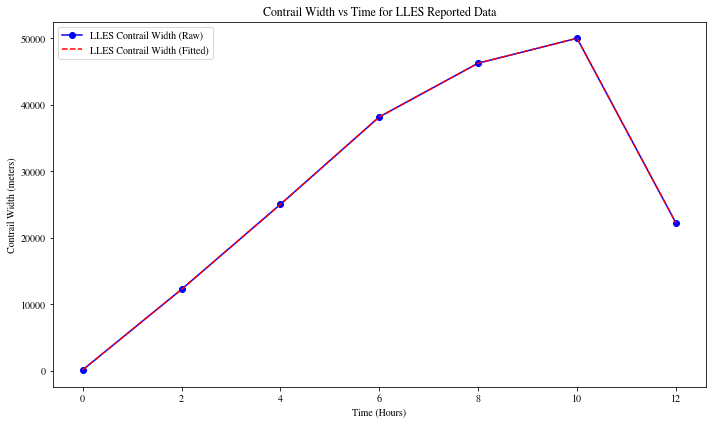

In [23]:
# Combined Contrail Width vs Time for LLES Reported Data (raw and fitted)
plt.figure(figsize=(10, 6))
plt.plot(LES_contrail_widths[0], LES_contrail_widths[1], label='LLES Contrail Width (Raw)', color='blue', marker='o')
plt.plot(times, LES_contrail_widths_fitted, label='LLES Contrail Width (Fitted)', color='red', linestyle='--')
plt.xlabel('Time (Hours)')
plt.ylabel('Contrail Width (meters)')
plt.title('Contrail Width vs Time for LLES Reported Data')
plt.legend()
plt.tight_layout()
plt.show()


### APCEMM

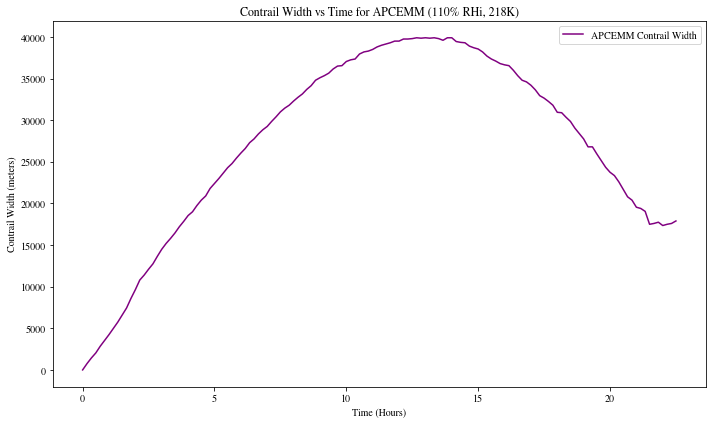

In [24]:
# Contrail Width vs Time for APCEMM Reported Data, RHi 110% 218K
apcemm_ds_list = epm_bypass_data['110T218L25']
apcemm_times = np.arange(len(apcemm_ds_list)) * 10 / 60  # time in hours (assuming 10 min per step)
apcemm_widths = []
for i, ds in enumerate(apcemm_ds_list):
    width = ds['width'].values.item()
    if i > 0 and width == 0:
        width = apcemm_widths[i-1]
    apcemm_widths.append(width)

plt.figure(figsize=(10, 6))
plt.plot(apcemm_times, apcemm_widths, label='APCEMM Contrail Width', color='purple')
plt.xlabel('Time (Hours)')
plt.ylabel('Contrail Width (meters)')
plt.title('Contrail Width vs Time for APCEMM (110% RHi, 218K)')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
print(f"The first recorded contrail width from APCEMM is: {apcemm_widths[0]:.2f} meters at time {apcemm_times[0]:.2f} hours.")
print(f"The recorded contrail width from APCEMM is: {apcemm_widths[3]:.2f} meters at time {apcemm_times[3]:.2f} hours.")

The first recorded contrail width from APCEMM is: 10.00 meters at time 0.00 hours.
The recorded contrail width from APCEMM is: 2050.00 meters at time 0.50 hours.


### CoCiP

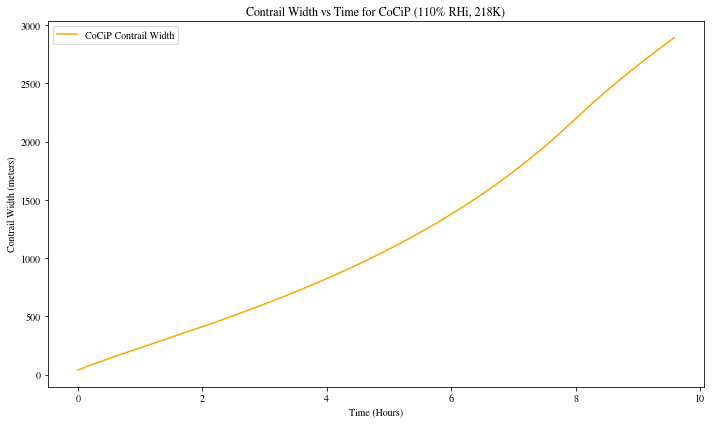

In [26]:
# Contrail Width vs Time for CoCiP Reported Data, RHi 110% 218K
cocip_ds = cocip_bypass_data['110T218L25']
cocip_times = cocip_ds['age_hours'].values  # time in hours
cocip_widths = cocip_ds['width'].values     # width in meters

plt.figure(figsize=(10, 6))
plt.plot(cocip_times, cocip_widths, label='CoCiP Contrail Width', color='orange')
plt.xlabel('Time (Hours)')
plt.ylabel('Contrail Width (meters)')
plt.title('Contrail Width vs Time for CoCiP (110% RHi, 218K)')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
print(f"The first recorded contrail width from CoCiP is: {cocip_widths[0]:.2f} meters at time {cocip_times[0]:.2f} hours.")

The first recorded contrail width from CoCiP is: 41.45 meters at time 0.00 hours.


### All 3 comparison

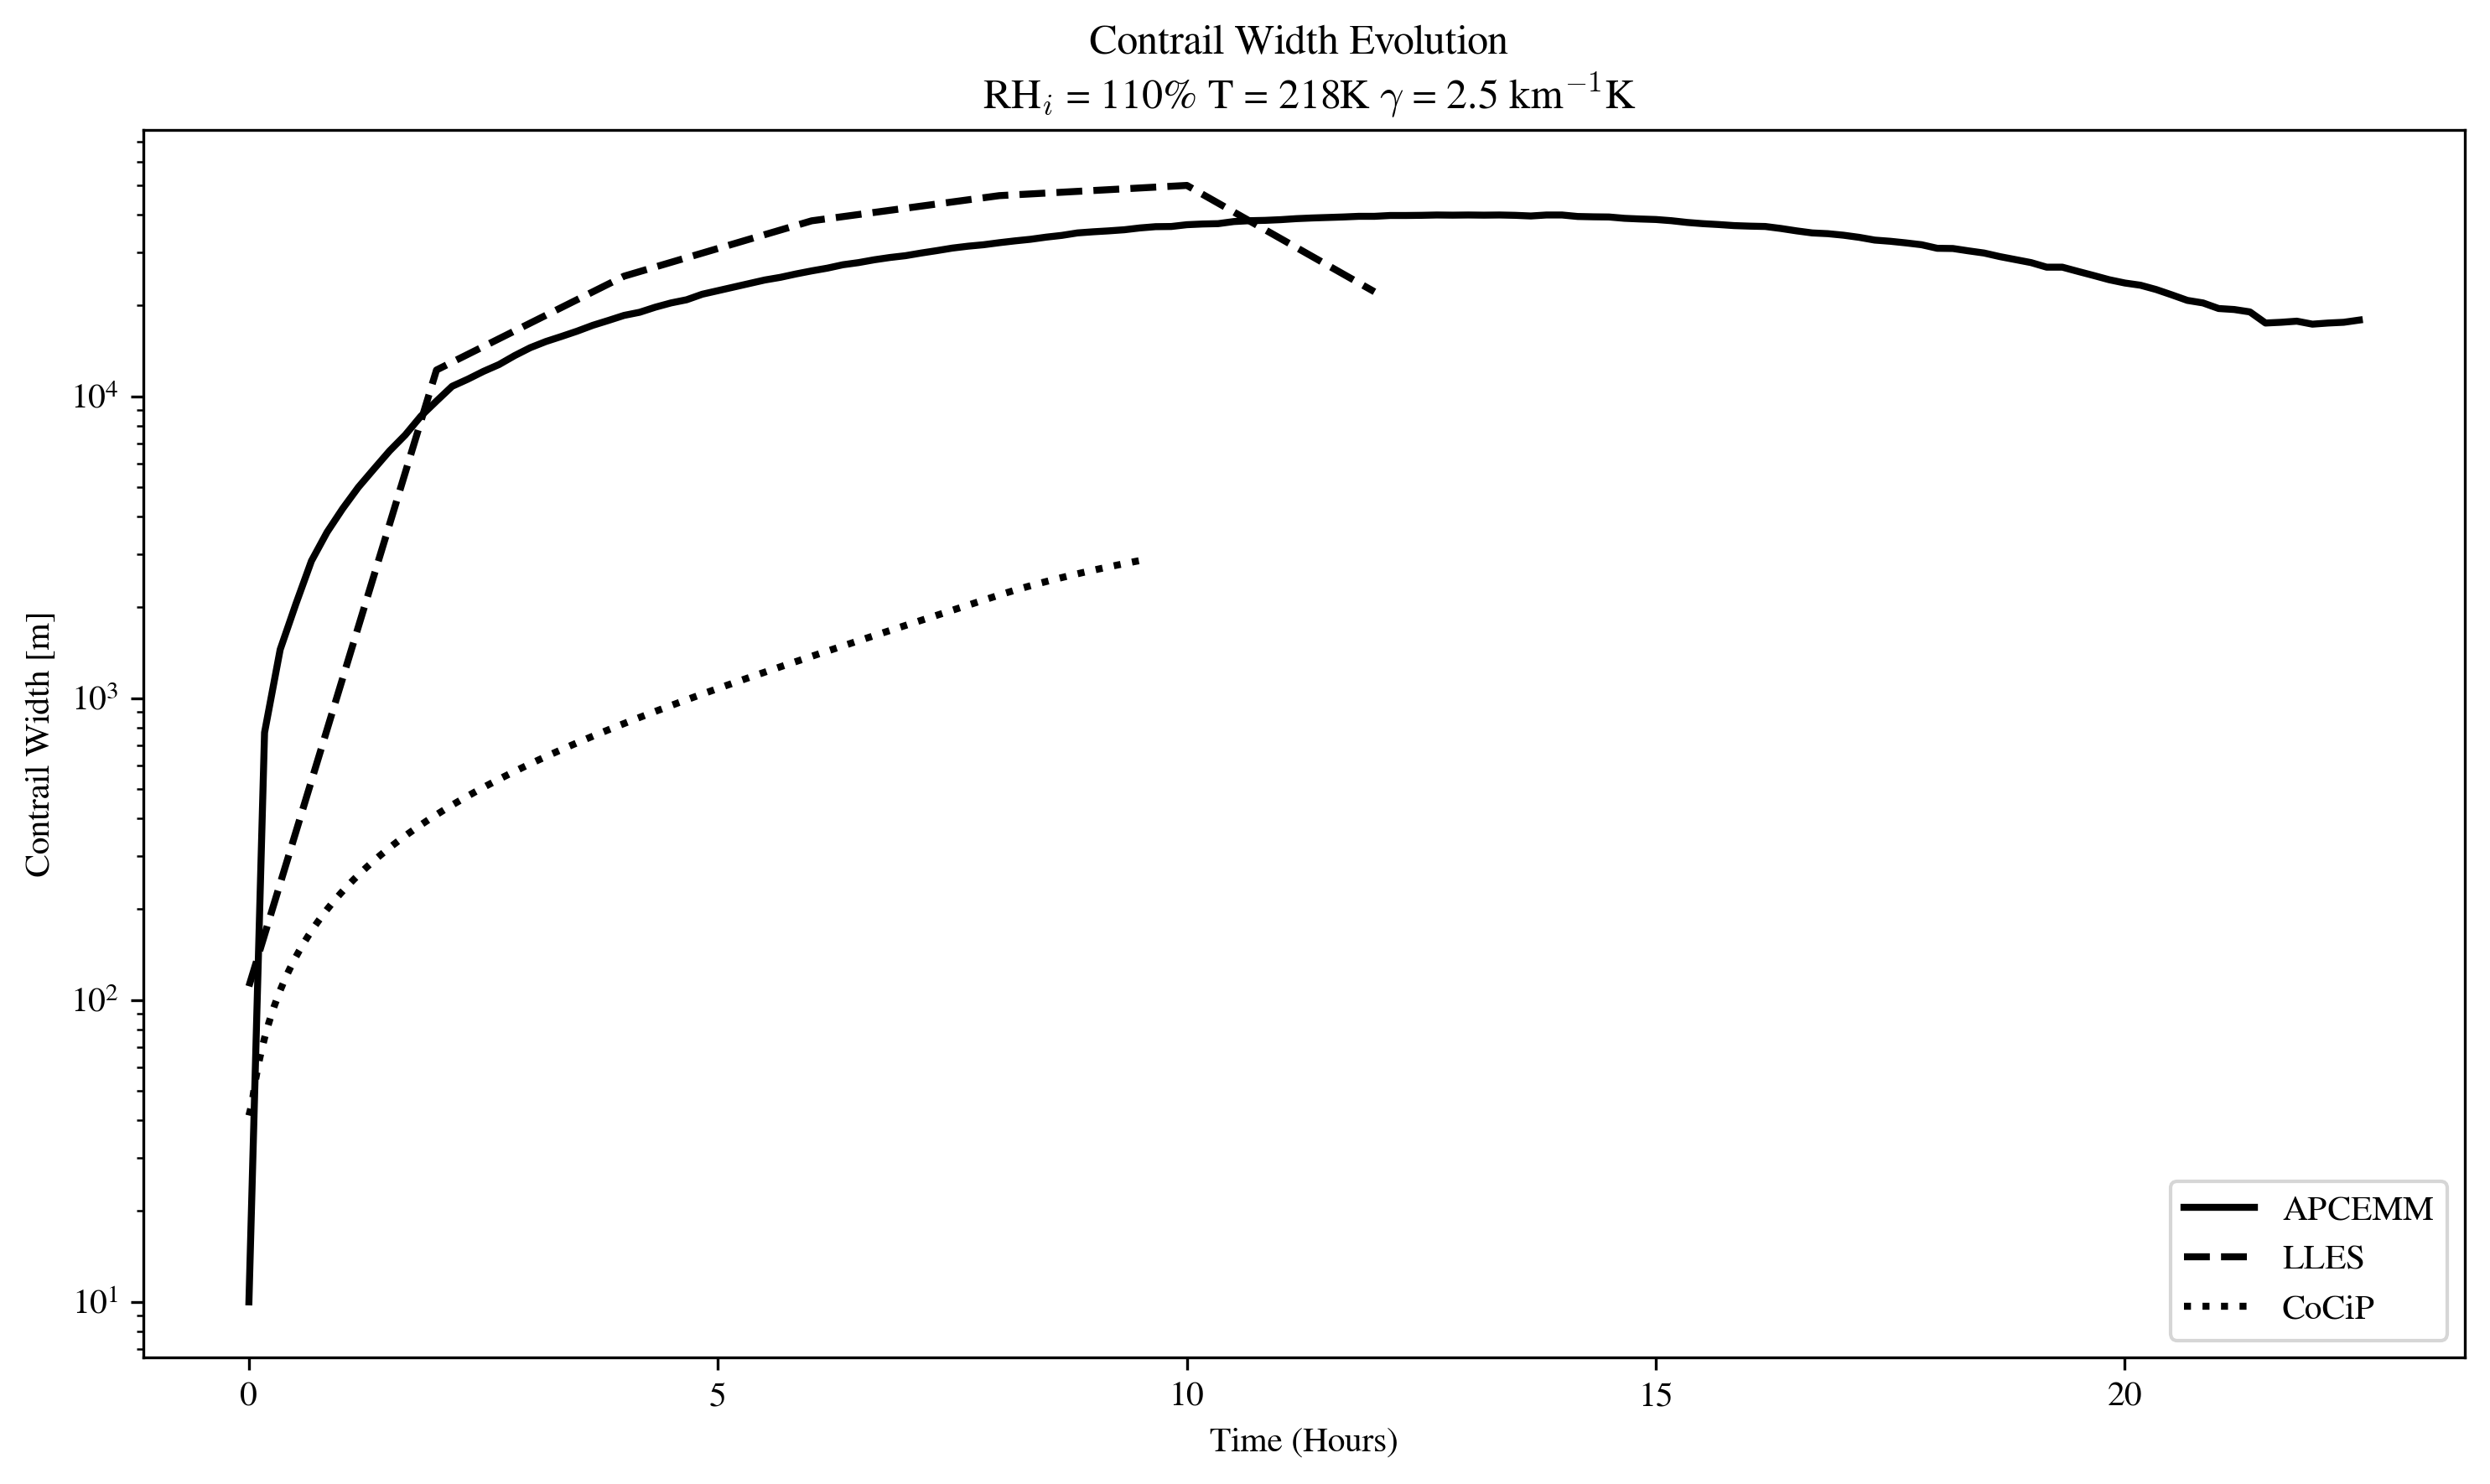

In [28]:
plt.figure(figsize=(10, 6), dpi=300)

# APCEMM contrail width
plt.plot(apcemm_times, apcemm_widths, label='APCEMM', color='black', linestyle='-', lw=2)

# LES contrail width
plt.plot(LES_contrail_widths[0], LES_contrail_widths[1], label='LLES', color='black', linestyle='--', lw=2)

# CoCiP contrail width
plt.plot(cocip_times, cocip_widths, label='CoCiP', color='black', linestyle=':', lw=2)

plt.xlabel('Time (Hours)')
plt.ylabel('Contrail Width [m]')
plt.yscale('log')
plt.title('Contrail Width Evolution \n RH$_i$ = 110% T = 218K $\gamma$ = 2.5 km$^{-1}$K')
plt.xticks(np.arange(0, 25, 5))
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Contrail Depth

### APCEMM

### CoCiP

### LLES

In [29]:
# Import contrail depth from digitized LLES data
LES_contrail_depths = pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/contrail_depth/{test_id}_D.csv", header=None)

In [30]:
# Fit the 6 data points to a smoothed curve
times = apcemm_times[apcemm_times <= LES_contrail_depths[0].max()]
LES_contrail_depths_fitted = interp1d(LES_contrail_depths[0], LES_contrail_depths[1], kind='linear')(times)

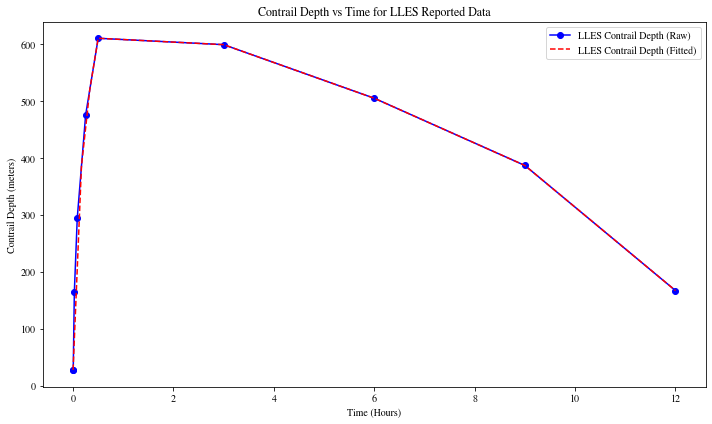

In [31]:
# Combined Contrail Depth vs Time for LLES Reported Data (raw and fitted)
plt.figure(figsize=(10, 6))
plt.plot(LES_contrail_depths[0], LES_contrail_depths[1], label='LLES Contrail Depth (Raw)', color='blue', marker='o')
plt.plot(times, LES_contrail_depths_fitted, label='LLES Contrail Depth (Fitted)', color='red', linestyle='--')
plt.xlabel('Time (Hours)')
plt.ylabel('Contrail Depth (meters)')
plt.title('Contrail Depth vs Time for LLES Reported Data')
plt.legend()
plt.tight_layout()
plt.show()


## Vertical Optical Depth

### Surface Area vs Time (LLES)

In [32]:
# Import surface areas from csv
ice_surface_area = pd.read_csv("/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/ice_surface_area/110T218L25_S.csv", header=None)
print("Number of data points in ice surface area:", ice_surface_area.shape[0])

Number of data points in ice surface area: 75


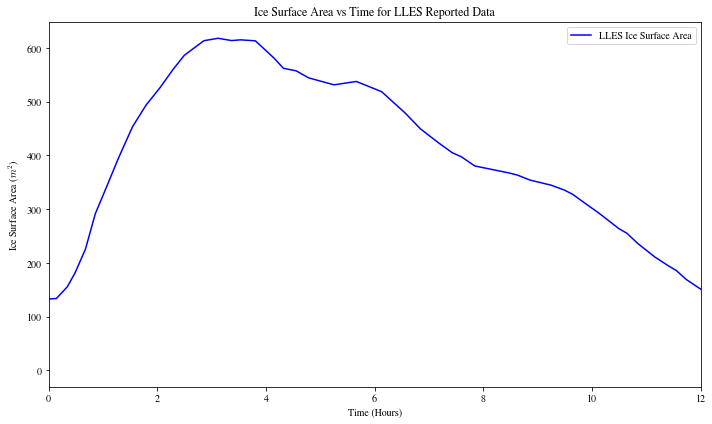

In [33]:
# Ice Surface Area vs Time for LLES Reported Data
plt.figure(figsize=(10, 6))
plt.plot(ice_surface_area[0], ice_surface_area[1], label='LLES Ice Surface Area', color='blue')
plt.xlabel('Time (Hours)')
plt.ylabel(r'Ice Surface Area ($m^{2}$)')
plt.xlim(0,12)
plt.title('Ice Surface Area vs Time for LLES Reported Data')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# LLES tau calculation, from Lewellen 2014 part 1
# Calculate the vertical integrated optical depth for each time step with an associated contrail width

def calculate_LLES_tau(S, W):
    tau = 0.5*S/W
    return tau

LES_tau = calculate_LLES_tau(ice_surface_area[1], LES_contrail_widths_fitted)

ValueError: operands could not be broadcast together with shapes (75,) (73,) 

In [ ]:
# Plot tau vs time
plt.figure(figsize=(10, 6))
plt.plot(times, LES_tau)
plt.xlabel("Time [hr]")
plt.ylabel("Vertical Optical Depth")
plt.title("LES Optical Depth")
plt.show()

### APCEMM

In [ ]:
# Plot the integrated optical depth from APCEMM data source for 110% 218K case
apcemm_intOD = []
ds_list = epm_bypass_data['110T218L25']
for i in range(len(ds_list)):
    val = ds_list[i]["intOD"].values.item()
    # If value > 1200 and not the first or last index, replace with average of previous and next
    if val > 1200 and 0 < i < len(ds_list) - 1:
        prev_val = ds_list[i - 1]["intOD"].values.item()
        next_val = ds_list[i + 1]["intOD"].values.item()
        avg_val = (prev_val + next_val) / 2
        apcemm_intOD.append(avg_val)
    else:
        apcemm_intOD.append(val)

plt.figure(figsize=(10,6), dpi=300)
plt.plot(apcemm_times, apcemm_intOD)

In [ ]:
# Plot the optical depth (tau) from APCEMM data source for 110% 218K case
apcemm_tau = []
for i, (intOD, width) in enumerate(zip(apcemm_intOD, apcemm_widths)):
    apcemm_tau.append(intOD / width)
apcemm_tau = np.array(apcemm_tau)
apcemm_times = np.arange(len(apcemm_tau)) * 10 / 60  # time in hours (10 min per step)

plt.figure(figsize=(10, 6))
plt.plot(apcemm_times, apcemm_tau, label='APCEMM Integrated Optical Depth', color='purple')
plt.xlabel('Time (Hours)')
plt.ylabel(r'Vertical Optical Depth, $\tau$')
plt.title('Optical Depth vs Time for APCEMM (110% RHi, 218K)')
plt.legend()
plt.tight_layout()
plt.show()

### CoCiP

In [ ]:
# Plot the integrated optical depth (tau) from CoCiP data source for 110% 218K case
# Calculate tau_contrail for CoCiP: intOD / width at each time step
cocip_ds = cocip_bypass_data['110T218L25']
cocip_tau = cocip_ds['tau_contrail'].values
cocip_times = cocip_ds['age_hours'].values

plt.figure(figsize=(10, 6))
plt.plot(cocip_times, cocip_tau, label='CoCiP Integrated Optical Depth', color='orange')
plt.xlabel('Time (Hours)')
plt.ylabel(r'Vertical Optical Depth, $\tau$')
plt.title('Optical Depth vs Time for CoCiP (110% RHi, 218K)')
plt.legend()
plt.tight_layout()
plt.show()

### All 3 comparision

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
# ax.set_yscale('log')

# APCEMM: tau vs time
ax.plot(apcemm_times, apcemm_tau, label='APCEMM', color='black', linestyle='-', lw=2)

# LES: tau vs time
ax.plot(times, LES_tau, label='LLES', color='black', linestyle='--', lw=2)

# CoCiP: tau vs time
ax.plot(cocip_times, cocip_tau, label='CoCiP', color='black', linestyle=':', lw=2)

ax.set_xlabel('Time [Hours]')
ax.set_ylabel('Vertical Optical Depth')
ax.set_title('Vertical Optical Depth Evolution \n RH$_i$ = 110% T = 218K $\gamma$ = 2.5 km$^{-1}$K')
ax.set_xticks(np.arange(0, 25, 5))

ax.legend()
plt.tight_layout()
plt.show()


## IWC

### APCEMM

In [ ]:
# From Fig 5 of ACCRI report
# meerkotter_iwc = 0.003085352024392664 #[g/m3]
# schumann_iwc = 0.0037077014125366896 #[g/m3]
fitted_iwc = 0.002076827107575895 #[g/m3]


#### Calculate IWC from ACCRI IWC fitting function

In [ ]:
def calculate_ACCRI_IWC(RHi, T):
    # T is in Kelvin
    # RHi is in %

    # Empirical fit based on ACCRI report data
    a = 1.1168
    b = 0.05592
    c = -0.0006265
    iwc = (RHi/100 -1)*np.exp(a + b*(T-273.15) + c*(T-273.15)**2)
    return iwc  # in g/m3

In [ ]:
# Calculate mass-weighted centroid altitude and temperature at centroid for each timestep
ds_list = epm_bypass_data[test_id]

n_steps = len(ds_list)
times_arr = np.arange(n_steps) * 10 / 60  # time in hours (assuming 10 min per step)
APCEMM_centroid_altitudes = np.full(n_steps, np.nan)
APCEMM_temperature_at_centroid = np.full(n_steps, np.nan)

for i, ds in enumerate(ds_list):
    # Extract arrays
    iwc = ds["IWC"].values  # expected shape (y, x)
    x = ds["x"].values
    y = ds["y"].values

    # cell sizes (fallback to 1.0 if single cell)
    dx = np.abs(x[1] - x[0]) if x.size > 1 else 1.0
    dy = np.abs(y[1] - y[0]) if y.size > 1 else 1.0

    # Create mesh for coordinates matching iwc shape
    X_map, Y_map = np.meshgrid(x, y)

    # Mass per cell (IWC [kg/m3] * cell volume [m * m * 1 m depth])
    mass_cell = iwc * dx * dy * 1.0
    total_mass = np.nansum(mass_cell)

    if total_mass > 0:
        # centroid altitude (mass-weighted)
        centroid_y = np.nansum(mass_cell * Y_map) / total_mass
        APCEMM_centroid_altitudes[i] = centroid_y

        # Determine temperature at centroid:
        T = ds['Temperature'].values
        # mass-weighted average temperature (consistent with centroid computation)
        APCEMM_temperature_at_centroid[i] = np.nansum(T * mass_cell) / total_mass


In [ ]:
# Plot centroid altitude vs time and temperature at centroid vs time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), dpi=150, sharex=True)

ax1.plot(times_arr[:n_steps], APCEMM_centroid_altitudes, color='tab:blue')
ax1.set_ylabel('Centroid Altitude (m)')
ax1.set_title(f'Contrail Mass Centroid Altitude vs Time ({test_id})')
ax1.grid(True)

ax2.plot(times_arr[:n_steps], APCEMM_temperature_at_centroid, color='tab:red')
ax2.set_xlabel('Time [hours]')
ax2.set_ylabel('Temperature at Centroid (K)')
ax2.set_title('Temperature at Mass Centroid vs Time')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print a small summary
print("First 5 centroid altitudes (m):", APCEMM_centroid_altitudes[:5])
print("First 5 temperatures at centroid (K):", APCEMM_temperature_at_centroid[:5])

In [ ]:
# Calculate IWC for 110% RHi and 218K (the average contrail case)
APCEMM_ACCRI_IWC_110T218 = calculate_ACCRI_IWC(110, APCEMM_temperature_at_centroid)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
ax.plot(times_arr, APCEMM_ACCRI_IWC_110T218, label='APCEMM-ACCRI IWC', color='black', linestyle='-', lw=2)
ax.set_xlabel('Time [Hours]')
ax.set_ylabel('IWC [g/m$^3$]')
ax.set_title('APCEMM-ACCRI IWC Evolution \n RH$_i$ = 110% T = 218K $\gamma$ = 2.5 km$^{-1}$K')
ax.set_xticks(np.arange(0, 25, 5))
ax.set_yscale('log')
ax.legend()
plt.show()  

#### Calculate APCEMM reported IWC

In [ ]:
# Plot APCEMM ice aerosol volume, effective radius, contrail width, depth, and total volume for 110% RHi, 218K
test_id = '110T218L25'
ds_list = epm_bypass_data[test_id]
times_arr = np.arange(len(ds_list)) * 10 / 60  # time in hours

# Calculate total contrail volume (IWC > 1e-3 kg/m^3) for each timestep in epm_bypass_data[test_id]
total_volumes = np.zeros(len(ds_list)) # [m3]
iwc = np.zeros(len(ds_list)) # [g/m3]
ice_aer_vol = np.zeros(len(ds_list)) # [m3/cm3]

for i, ds in enumerate(epm_bypass_data[test_id]):
    iwc_2d = ds["IWC"].values * 1e3  # Convert to g/m^3
    ice_aer_vol_2d = ds["Ice aerosol volume"].values  # [m3/cm3]

    x = ds["x"].values
    y = ds["y"].values
    dx = np.abs(x[1] - x[0]) if len(x) > 1 else 1.0
    dy = np.abs(y[1] - y[0]) if len(y) > 1 else 1.0
    mask = iwc_2d > 1e-3 # True False mask
    num_contrail_contain_cells = np.sum(mask)
    total_volume = num_contrail_contain_cells * dx * dy * 1.0
    total_volumes[i] = total_volume

    masked_iwc = np.array(iwc_2d[mask])
    
    if masked_iwc.size == 0 or ice_aer_vol_2d[mask].size == 0:
        iwc[i] = 0.0
        ice_aer_vol[i] = 0.0
        continue

    iwc[i] = np.mean(masked_iwc) # Take the mean of the values associated with True in the mask (1D array) # [g/m3]
    ice_aer_vol[i] = np.mean((ice_aer_vol_2d[mask])) # Take the mean of the values associated with True in the mask (1D array) # [m3/cm3]

# Extract data
ice_vol = ice_aer_vol * total_volumes * 1e6  # [m3/cm3] * [m3] * [cm3/m3] --> [m3]
iwc_calc = ice_vol/(np.array(total_volumes)*1e6)  # [m3/cm3]

#### Check that APCEMM IWC matches with other outputs

In [ ]:

fig, ax1 = plt.subplots(figsize=(12, 7), dpi=300)

color1 = 'tab:blue'
color2 = 'tab:orange'
color3 = 'tab:green'

# Plot IWC (mean in g/m3)
ax1.plot(times_arr[1:], iwc[1:], color=color1, label='Mean IWC [g/m³]')
ax1.set_ylabel('Mean IWC [g/m³]', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.plot(times_arr, [fitted_iwc]*len(times_arr), color='green', linestyle='--', label='Fitted IWC')

# Second y-axis for ice_vol
ax2 = ax1.twinx()
ax2.plot(times_arr, ice_vol, color=color2, label='Ice Volume [m³]')
ax2.set_ylabel('Ice Volume [m³]', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Third y-axis for total_volumes
ax3 = ax1.twinx()
ax3.spines.right.set_position(("axes", 1.15))
ax3.plot(times_arr, total_volumes*1e6, color=color3, label='Total Volume [cm³]')
ax3.set_ylabel('Total Contrail Volume [cm³]', color=color3)
ax3.tick_params(axis='y', labelcolor=color3)

ax1.axvline(5*10/60, color='black', linewidth=0.8, label='Peak IWC', linestyle='--')
ax1.set_xlabel("Time [hours]")
ax1.set_title("APCEMM: IWC, Ice Volume, and Total Contrail Volume\nRHi = 110%, T = 218K")

# Combine legends
lines = ax1.get_lines() + ax2.get_lines() + ax3.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.show()

#### Compare APCEMM predicted IWC to ACCRI/SUCCESS IWC

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
ax.plot(APCEMM_temperature_at_centroid, APCEMM_ACCRI_IWC_110T218, label='APCEMM-ACCRI IWC', color='black', linestyle='-', lw=2)
ax.plot(APCEMM_temperature_at_centroid, iwc, label='APCEMM Mean IWC', color='tab:blue', linestyle='-', lw=2)

ax.set_xlabel('Temperature [K]')
ax.set_ylabel('IWC [g/m$^3$]')
ax.set_title('IWC Comparison \n RH$_i$ = 110% T = 218K $\gamma$ = 2.5 km$^{-1}$K')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

### CoCiP

In [ ]:
# Calculate IWC for 110% RHi and 218K (the average contrail case)
cocip_altitude = cocip_ds['altitude']
cocip_temperature_at_centroid = cocip_ds['air_temperature'].values
cocip_ACCRI_IWC_110T218 = calculate_ACCRI_IWC(110, cocip_temperature_at_centroid)

cocip_iwc = cocip_ds['iwc'].values * cocip_ds['rho_air'] * 1000  # [kg ice/ kg air]*[kg air/m3]*1000 = [g/m3]

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
ax.plot(cocip_temperature_at_centroid, cocip_ACCRI_IWC_110T218, label='CoCiP-ACCRI IWC', color='black', linestyle='-', lw=2)
ax.plot(cocip_temperature_at_centroid, cocip_iwc, label='CoCiP Mean IWC', color='tab:blue', linestyle='-', lw=2)

ax.set_xlabel('Temperature [K]')
ax.set_ylabel('IWC [g/m$^3$]')
ax.set_title('IWC Comparison \n RH$_i$ = 110% T = 218K $\gamma$ = 2.5 km$^{-1}$K')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

### LLES

#### Calculate IWC from LLES data

In [ ]:
# Import LLES IWC data from csv
LLES_iwc_data = pd.read_csv("/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/IWC/110T218L25_IWC.csv")

In [ ]:
LLES_iwc_times = LLES_iwc_data['Time_hours'].values
LLES_iwc_values = LLES_iwc_data['IWC_g_per_m3'].values

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
ax.plot(LLES_iwc_times, LLES_iwc_values, label='LLES Mean IWC', color='black', linestyle='-', lw=2)
ax.set_xlabel('Time [Hours]')
ax.set_ylabel('IWC [g/m$^3$]')
ax.set_xticks(np.arange(0, 25, 5))
ax.set_title('LLES IWC Evolution \n RH$_i$ = 110% T = 218K $\gamma$ = 2.5 km$^{-1}$K')
# ax.set_yscale('log')

### All together

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Scatter points for each dataset
ax.scatter(APCEMM_temperature_at_centroid[1:]-273.15, iwc[1:], label='APCEMM Mean IWC', color='tab:blue', marker='o', s=4, alpha=0.9)
ax.scatter(cocip_temperature_at_centroid-273.15, cocip_iwc, label='CoCiP Mean IWC', color='tab:orange', marker='s', s=4, alpha=0.9)
ax.scatter(APCEMM_temperature_at_centroid[:len(LLES_iwc_values)]-273.15, LLES_iwc_values, label='LLES Mean IWC', color='tab:green', marker='^', s=4, alpha=0.9)

ax.set_xlabel('Temperature [C]')
ax.set_ylabel('IWC [g/m$^3$]')
ax.set_title('IWC Comparison \n RH$_i$ = 110% T = 218K $\gamma$ = 2.5 km$^{-1}$K')
ax.set_yscale('log')
ax.legend()
ax.set_xlim(-55, -49)
plt.tight_layout()
plt.show()


#### Plot centroid altitude as function of time (checking temperature approximation)

In [ ]:
# Plot CoCiP and APCEMM mass-centroid altitudes vs time (for test_id in current context)

# Plot both
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.plot(apcemm_times, APCEMM_centroid_altitudes + 10700, linestyle='-', color='tab:blue', label='APCEMM centroid altitude')
ax.plot(cocip_times, cocip_altitude, linestyle='-', color='tab:orange', label='CoCiP centroid altitude')
ax.axhline(10200, color='gray', linestyle=':', label='End of Supersaturated Layer (10,200 m)')

plt.xlabel('Time [hours]')
plt.ylabel('Centroid Altitude [m]')
plt.title(f'Centroid Altitude vs Time ({test_id})')
plt.legend()
plt.tight_layout()
plt.show()